$$n_{\mathrm{e}, \min }^{\text {scal }} \approx 0.7 I_{\mathrm{p}}^{0.34} B_{T}^{0.62} a^{-0.95}(R / a)^{0.4}$$


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [18]:
file_path = 'LH_metal_DB_v1.12.csv'  # 替换为你的文件路径
df = pd.read_csv(file_path)
df.loc[:, 'TOK'] = df['TOK'].str.strip()
df['IP']=df['IP'].abs()/1000000

reference_dict = {
    1.00:  "Hydrogen",
    2.00:  "Deuterium",
    2.50:  "Deuterium and tritium",
    3.00:  "3He or tritium",
    4.00:  "4He",
    14.01: "Nitrogen"
}

# 定义一个函数，用来根据某一观测值PGASA，返回对应的分类名称
def categorize_pgasa(value, ref_dict, tolerance=0.2):
    """
    value: 待分类的数值
    ref_dict: {参考值: 分类名称}
    tolerance: 容忍度，即 |value - 参考值| 需小于等于该值才视为同一类
    """
    # 1) 找到离 value 最近的参考值
    closest_ref = min(ref_dict.keys(), key=lambda x: abs(x - value))
    # 2) 判断两者差值是否在容忍度以内
    if abs(closest_ref - value) <= tolerance:
        return ref_dict[closest_ref]
    else:
        return np.nan  # 或者 "Other"

# 将 categorize_pgasa 应用于 df["PGASA"] 列，生成新的分类列
df["Category"] = df["PGASA"].apply(lambda x: categorize_pgasa(x, reference_dict, tolerance=0.25))




subset1 = df[df['TOK'] == 'CMOD']
subset2 = df[df['TOK'] == 'AUG']
subset3 = df[df['TOK'] == 'JET']




In [19]:
colors_map = {1: ('red', 'high-branch'), 0: ('blue', 'low-branch')}

bt = subset1['BT']

# 分类 BT 值
subset1['Nemin'] = np.nan
subset1.loc[(bt <= 7.6) , 'Nemin'] = 1.4e20

/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_1404/4260273593.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset1['Nemin'] = np.nan


In [20]:
import pandas as pd
import numpy as np

x = subset2['NEL']
y = subset2['PLTH']
ip = subset2['IP']

# 初始化 Nemin 列（可选）
subset2['Nemin'] = np.nan

# 分类并直接赋值
subset2.loc[(ip < 0.7) & (subset2['Category'] != 'Hydrogen'), 'Nemin'] = np.nan
subset2.loc[(ip >= 0.7) & (ip < 0.81) & (subset2['Category'] != 'Hydrogen'), 'Nemin'] = 3.0e19
subset2.loc[(ip >= 0.9) & (subset2['Category'] != 'Hydrogen'), 'Nemin'] = 3.5e19
subset2.loc[subset2['Category'] == 'Hydrogen', 'Nemin'] = 4.5e19


/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_1404/1163508340.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset2['Nemin'] = np.nan


In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 假设 subset1 是你的数据框
colors = subset3['SELEC2024'].map({1: 'red', 0: 'blue'})
colors_map = {1: ('red', 'high-branch'), 0: ('blue', 'low-branch')}
x = subset3['NEL']
y = subset3['PLTH']
bt = subset3['BT'].abs()
ip= subset3['IP']

subset3['Nemin'] = np.nan

# 条件赋值
subset3.loc[
    (bt < 1.5) & (bt >= 1.1) &
    (subset3['Category'] == 'Deuterium') &
    (subset3['DIVCON'].isin(['VT', 'CORNER'])),
    'Nemin'
] = np.nan

subset3.loc[
    (bt < 2.0) & (bt >= 1.5) &
    (subset3['Category'] == 'Deuterium') &
    (subset3['DIVCON'].isin(['V5', 'V5L'])),
    'Nemin'
] = 2.2e19

subset3.loc[
    (bt < 2.0) & (bt >= 1.5) &
    (subset3['Category'] == 'Hydrogen') &
    (subset3['DIVCON'] == 'V5'),
    'Nemin'
] = np.nan

subset3.loc[
    (bt < 2.0) & (bt >= 1.5) &
    (subset3['Category'].isin(['Deuterium and tritium', '3He or tritium'])) &
    (subset3['DIVCON'] == 'V5'),
    'Nemin'
] = np.nan

subset3.loc[
    (bt < 2.0) & (bt >= 1.5) &
    (subset3['Category'] == 'Deuterium') &
    (subset3['DIVCON'] == 'CORNER'),
    'Nemin'
] = np.nan

subset3.loc[
    (bt < 2.0) & (bt >= 1.5) &
    (subset3['Category'] == 'Hydrogen') &
    (subset3['DIVCON'].isin(['VT', 'CORNER'])),
    'Nemin'
] = np.nan

/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_1404/3361217845.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset3['Nemin'] = np.nan


In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 假设 subset1 是你的数据框
colors_map = {1: ('red', 'high-branch'), 0: ('blue', 'low-branch')}
colors = subset3['SELEC2024'].map({1: 'red', 0: 'blue'})
x = subset3['NEL']
y = subset3['PLTH']
bt = subset3['BT'].abs()
ip= subset3['IP']



# 条件赋值
subset3.loc[
    (ip < 2.3) & (ip >= 1.7) &
    (bt < 2.6) & (bt >= 2.0) &
    (subset3['Category'] == 'Deuterium') &
    (subset3['DIVCON'].isin(['V5E', 'V5C','V5','HT3R','HT3'])),
    'Nemin'
] = 2.85e19

subset3.loc[
    (ip < 2.3) & (ip >= 1.7) &
    (bt < 2.6) & (bt >= 2.0) &
    (subset3['Category'] == 'Deuterium') &
    (subset3['DIVCON'].isin(['V5L','HT3L'])),
    'Nemin'
] = 2.7e19

subset3.loc[
    (ip < 2.3) & (ip >= 1.7) &
    (bt < 2.6) & (bt >= 2.0) &
    (subset3['Category'] == 'Deuterium') &
    (subset3['DIVCON'].isin(['VT', 'CORNER'])),
    'Nemin'
] = 2.0e19

subset3.loc[
    (ip < 1.7) & (ip >= 1.2) &
    (bt < 2.6) & (bt >= 2.0) &
    (subset3['Category'] == 'Deuterium')&
    (subset3['DIVCON'] == 'V5'),
    'Nemin'
] = np.nan

subset3.loc[
    (ip < 2.3) & (ip >= 1.7) &
    (bt < 2.6) & (bt >= 2.0) &
    (subset3['Category'].isin(['3He or tritium', 'Deuterium and tritium'])) &
    (subset3['DIVCON'] == 'V5'),
    'Nemin'
] = 2.2e19


In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 假设 subset1 是你的数据框
colors = subset3['SELEC2024'].map({1: 'red', 0: 'blue'})
x = subset3['NEL']
y = subset3['PLTH']
bt = subset3['BT'].abs()
ip= subset3['IP']



# 各条件对应 Nemin 的赋值
subset3.loc[
    (ip < 2.80) & (ip >= 1.9) &
    (bt < 3.5) & (bt >= 2.8) &
    (subset3['Category'] == 'Deuterium') &
    (subset3['DIVCON'].isin(['V5', 'HT3R'])),
    'Nemin'
] = 3.2e19

subset3.loc[
    (ip < 2.6) & (ip >= 2.4) &
    (bt < 3.2) & (bt >= 2.8) &
    (subset3['Category'] == 'Deuterium') &
    (subset3['DIVCON'] == 'VT'),
    'Nemin'
] = np.nan

subset3.loc[
    (ip < 4.1) & (ip >= 1.9) &
    (bt < 3.75) & (bt >= 2.75) &
    (subset3['Category'] == 'Deuterium') &
    (subset3['DIVCON'] == 'CORNER'),
    'Nemin'
] = np.nan

subset3.loc[
    (ip < 2.6) & (ip >= 2.4) &
    (bt < 3.2) & (bt >= 2.8) &
    (subset3['Category'] == '3He or tritium') &
    (subset3['DIVCON'] == 'V5'),
    'Nemin'
] = 2.7e19

subset3.loc[
    (ip < 2.6) & (ip >= 2.4) &
    (bt < 3.2) & (bt >= 2.8) &
    (subset3['Category'] == 'Deuterium and tritium') &
    (subset3['DIVCON'] == 'V5'),
    'Nemin'
] = 3.1e19



In [24]:
'''
# 筛选出 Nemin == 3.1e19 的数据
subset_nemin = subset2[(subset2['Nemin'] == 4.5e19) ]#& (subset3['BT'].abs() <= 2.5)]

# 设置图形尺寸
plt.figure(figsize=(12, 5))

# 绘制 IP 的分布图
plt.subplot(1, 2, 1)
plt.hist(subset_nemin['IP'], bins=15, color='salmon', edgecolor='black', alpha=0.8)
plt.title('Distribution of IP (Nemin = 3.1e19)')
plt.xlabel('IP')
plt.ylabel('Frequency')
plt.grid(True)

# 绘制 BT 的分布图
plt.subplot(1, 2, 2)
plt.scatter(range(len(subset_nemin['ZEFF'])),subset_nemin['ZEFF'])
plt.title('Distribution of BT (Nemin = 3.1e19)')
plt.xlabel('BT')
plt.ylabel('Frequency')
plt.grid(True)

plt.tight_layout()
plt.show()
'''

"\n# 筛选出 Nemin == 3.1e19 的数据\nsubset_nemin = subset2[(subset2['Nemin'] == 4.5e19) ]#& (subset3['BT'].abs() <= 2.5)]\n\n# 设置图形尺寸\nplt.figure(figsize=(12, 5))\n\n# 绘制 IP 的分布图\nplt.subplot(1, 2, 1)\nplt.hist(subset_nemin['IP'], bins=15, color='salmon', edgecolor='black', alpha=0.8)\nplt.title('Distribution of IP (Nemin = 3.1e19)')\nplt.xlabel('IP')\nplt.ylabel('Frequency')\nplt.grid(True)\n\n# 绘制 BT 的分布图\nplt.subplot(1, 2, 2)\nplt.scatter(range(len(subset_nemin['ZEFF'])),subset_nemin['ZEFF'])\nplt.title('Distribution of BT (Nemin = 3.1e19)')\nplt.xlabel('BT')\nplt.ylabel('Frequency')\nplt.grid(True)\n\nplt.tight_layout()\nplt.show()\n"

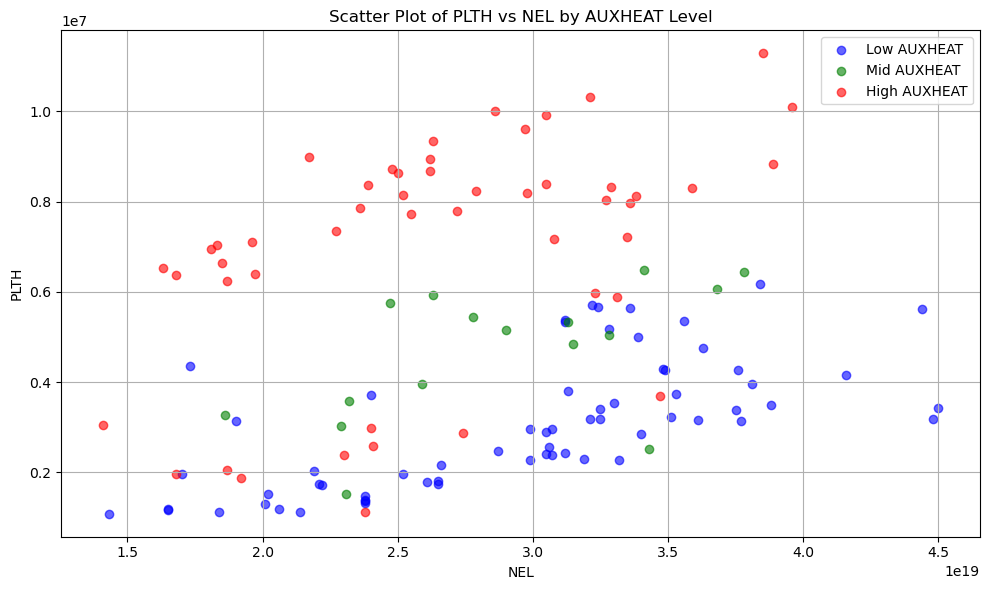

In [25]:
import matplotlib.pyplot as plt

# 筛选 Nemin = 3.1e19 且 abs(BT) <= 2.5 的数据
df_filtered = subset3[(subset3['BT'].abs() <= 2.0)]

import matplotlib.pyplot as plt
import pandas as pd

# 根据 AUXHEAT 的分位数分成三组
low_thresh = df_filtered['BT'].quantile(1/3)
high_thresh = df_filtered['BT'].quantile(2/3)

# 创建三组子集
low_aux = df_filtered[df_filtered['BT'] <= -1.80]
mid_aux = df_filtered[(df_filtered['BT'] > -1.80) & (df_filtered['BT'] <= -1.78)]
high_aux = df_filtered[df_filtered['BT'] > -1.78]

# 设置画布
plt.figure(figsize=(10, 6))

# 画三个组的散点图
plt.scatter(low_aux['NEL'], low_aux['PLTH'], color='blue', label='Low AUXHEAT', alpha=0.6)
plt.scatter(mid_aux['NEL'], mid_aux['PLTH'], color='green', label='Mid AUXHEAT', alpha=0.6)
plt.scatter(high_aux['NEL'], high_aux['PLTH'], color='red', label='High AUXHEAT', alpha=0.6)

# 添加图例和标签
plt.xlabel('NEL')
plt.ylabel('PLTH')
plt.title('Scatter Plot of PLTH vs NEL by AUXHEAT Level')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [26]:
combined_df = pd.concat([ subset1,subset2, subset3])
combined_df

,TOK,SHOT,TIME,PHASE,PGASA,RGEO,AMIN,KAPPA,SPLASMA,CONFIG,...,PLTH,PFLOSS,PRADCORE,DIVCON,FRACNMIN,LHTIME,AUXHEAT,SELEC2024,Category,Nemin
0,CMOD,1050428004,0.63461,LH,2.000,0.672389,0.216421,1.69737,7.42158,SN,...,2289520,0.0,0,VERTPLT,-1.000000e-08,0.63561,IC,1,Deuterium,1.400000e+20
1,CMOD,1050428007,0.66603,LH,2.000,0.670773,0.217660,1.67073,7.36968,SN,...,1165300,0.0,0,VERTPLT,-1.000000e-08,0.66703,IC,0,Deuterium,1.400000e+20
2,CMOD,1050621015,0.91039,LH,2.000,0.672785,0.217388,1.67962,7.37796,SN,...,1424930,0.0,0,VERTPLT,-1.000000e-08,0.91139,IC,1,Deuterium,1.400000e+20
3,CMOD,1050621029,0.85420,LH,2.000,0.670869,0.217080,1.69789,7.43647,SN,...,1372730,0.0,0,VERTPLT,-1.000000e-08,0.85520,IC,1,Deuterium,1.400000e+20
4,CMOD,1050623008,0.80070,LH,2.000,0.678764,0.213690,1.44202,6.70529,SN,...,1791100,0.0,0,VERTPLT,-1.000000e-08,0.80170,IC,1,Deuterium,1.400000e+20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,JET,90527,50.99500,LH,1.962,2.900090,0.933780,1.66731,138.51000,SN(B),...,5172080,134462.0,998469,CORNER,0.000000e+00,51.03000,NB,0,Deuterium,NaN
686,JET,90528,55.16500,LH,1.916,2.901440,0.933319,1.66831,138.53000,SN(B),...,8965160,257820.0,1581660,CORNER,0.000000e+00,55.20000,NB,1,Deuterium,NaN
687,JET,90737,54.56500,LH,1.940,2.901330,0.934255,1.66599,138.48200,SN(B),...,7676990,300914.0,-,CORNER,0.000000e+00,54.60000,NB,0,Deuterium,NaN
688,JET,90738,54.46500,LH,1.961,2.898400,0.937640,1.65848,138.70400,SN(B),...,6755910,255093.0,1077560,CORNER,0.000000e+00,54.50000,NB,0,Deuterium,NaN


In [27]:
nan_indices = combined_df[combined_df['Nemin'].isnull()].index

# 删除这些行
combined_df = combined_df.drop(nan_indices)

In [28]:
# 合并三个 DataFrame


$$n_{\mathrm{e}, \min }^{\text {scal }} \approx 0.7 I_{\mathrm{p}}^{0.34} B_{T}^{0.62} a^{-0.95}(R / a)^{0.4}$$


In [29]:

df = combined_df
df.loc[:, 'TOK'] = df['TOK'].str.strip()

df['PLTH']=df['PLTH']/1000000
df['NEL']=df['NEL']/1e19
df['a']=df['RGEO']/df['AMIN']
df['Nemin']=df['Nemin']/1e19
df['BT']=df['BT'].abs()

In [31]:
nan_indices = df[df['Nemin'].isnull()].index


Index([], dtype='int64')

In [50]:

import statsmodels.api as sm

# 指定你想在新 DataFrame 中包含的列
columns_to_include = ['TOK','Nemin', 'SPLASMA','BT','IP','a','AMIN','RGEO','PLTH','NEL','PGASA',"DIVCON"]
new_df = df[columns_to_include].copy()
mu0 = 4 * np.pi * 1e-7

new_df['BP']=1000000*(mu0 * new_df['IP']) / (new_df['SPLASMA']/(2 * np.pi * new_df['RGEO']))

new_df['PLTH/S/2']=new_df['PLTH']/(new_df['SPLASMA']*2)



columns_to_include_for_regre = ['Nemin','PGASA','IP','BT','AMIN','a']
unique_divcon = new_df['DIVCON'].unique()

# 2. 向原始 DataFrame 添加新列
for divcon_type in unique_divcon:
    new_df[divcon_type] = (new_df['DIVCON'] == divcon_type).astype(int)
multi_df = new_df[columns_to_include_for_regre].copy()
multi_df = multi_df.apply(np.log)
x = multi_df[['IP','BT','AMIN','a']] 
#x[unique_divcon] = new_df[unique_divcon]
#x['Xp'] = x[['Xptref','Xpthigh','Xptin']].max(axis=1)
#x.drop(['STANDARD'], axis=1, inplace=True)
#x.drop(['Xptref','Xpthigh','Xptin'], axis=1, inplace=True)
#x['hor'] = x[['V5E','V5C','V5L']].max(axis=1)
#x.drop(['V5E'], axis=1, inplace=True)
X_with_intercept = sm.add_constant(x)
y=multi_df["Nemin"]
model = sm.OLS(y, X_with_intercept)
results = model.fit()

# 打印详细统计结果
print(results.summary())

# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")
    # 打印 RMSE
y_pred = results.predict(X_with_intercept)  # 预测值
rmse = np.sqrt(np.mean((np.exp(y) - np.exp(y_pred)) ** 2))  # 计算 RMSE

print(f"RMSE: {rmse:.3f}")
# 获取 90% 置信区间
conf_int_90 = results.conf_int(alpha=0.1)


print("\n90% 置信区间：\n", conf_int_90)
new_df[columns_to_include_for_regre]

                            OLS Regression Results                            
Dep. Variable:                  Nemin   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     2534.
Date:                Sun, 11 May 2025   Prob (F-statistic):          1.52e-321
Time:                        02:03:04   Log-Likelihood:                 392.17
No. Observations:                 486   AIC:                            -774.3
Df Residuals:                     481   BIC:                            -753.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0020      0.329      9.111      0.0

,Nemin,PGASA,IP,BT,AMIN,a
0,14.0,2.000,0.931812,5.33923,0.216421,3.106857
1,14.0,2.000,0.655357,5.35375,0.217660,3.081747
2,14.0,2.000,0.634247,5.32586,0.217388,3.094858
3,14.0,2.000,1.030660,5.33346,0.217080,3.090423
4,14.0,2.000,0.681653,5.26510,0.213690,3.176396
...,...,...,...,...,...,...
663,3.2,1.972,2.470630,2.97606,0.928461,3.111989
664,3.2,1.979,2.715140,2.97667,0.924404,3.128751
665,3.2,1.972,2.716620,2.97529,0.925206,3.125769
666,3.2,1.991,2.721300,2.97753,0.926219,3.120903


In [51]:
df['y_pred']=np.exp(y_pred)
df['y']=np.exp(y)

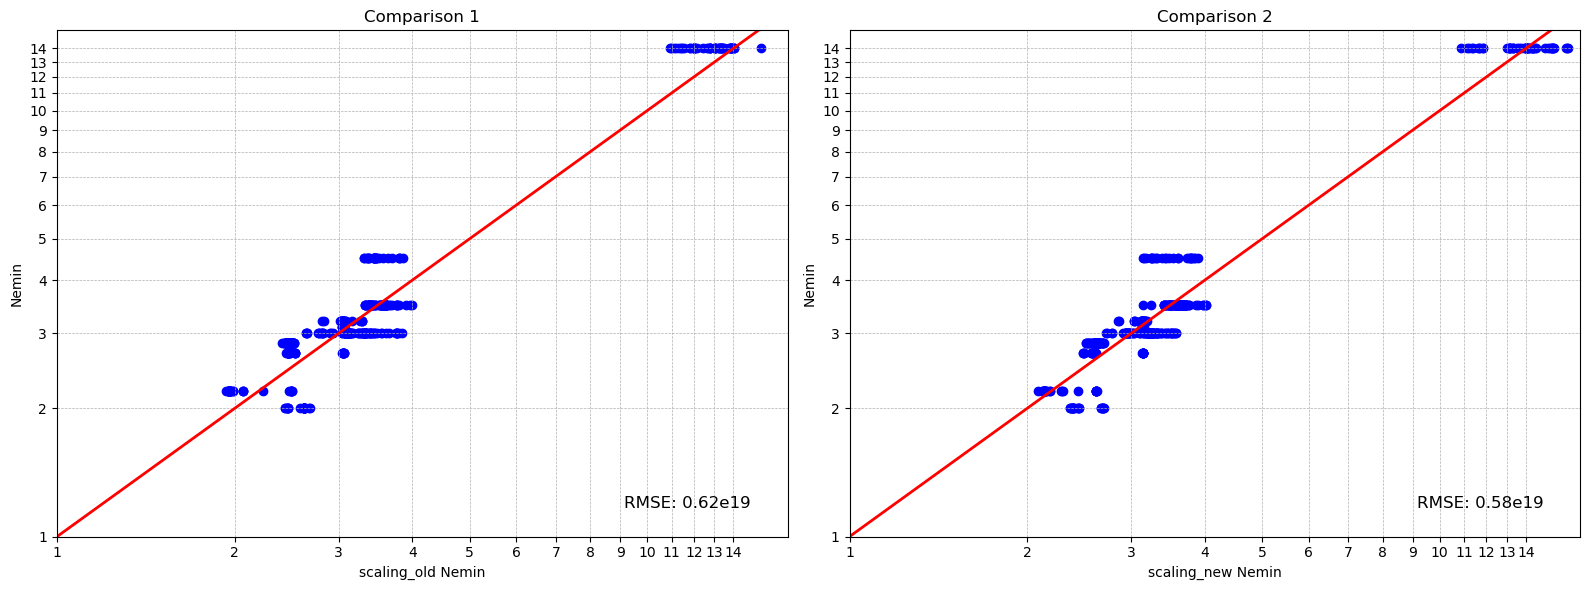

In [15]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter
import pandas as pd
import numpy as np

# 假设 df 已经存在并包含以下列：IP, BT, AMIN, a, Nemin
# 定义公式和计算理想值
df['scaling_nemin_scal'] = 0.7 * (df['IP']**0.34) * (df['BT']**0.62) * (df['AMIN']**(-0.95)) * (df['a']**0.4)

# 创建一行两列的图形
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 第一张图
ax1.scatter(df['scaling_nemin_scal'], df['Nemin'], color='blue', label='Actual Nemin')
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('scaling_old Nemin')
ax1.set_ylabel('Nemin')
ax1.set_title('Comparison 1')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.xaxis.set_major_formatter(ScalarFormatter())
ax1.yaxis.set_major_formatter(ScalarFormatter())

# 设置 x 和 y 轴的范围
ax1.set_xlim(left=1)
ax1.set_ylim(bottom=1)
x_start, x_end = ax1.get_xlim()
y_start, y_end = ax1.get_ylim()
line_start = max(x_start, y_start)
line_end = min(x_end, y_end)
ax1.plot([line_start, line_end], [line_start, line_end],
         color='red', label='scaling Fit', linewidth=2)
# 第二张图（可以更改为不同的比较内容）
ax2.scatter(np.exp(y_pred), np.exp(y), color='blue', label='Actual Nemin')
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('scaling_new Nemin')
ax2.set_ylabel('Nemin')
ax2.set_title('Comparison 2')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.xaxis.set_major_formatter(ScalarFormatter())
ax2.yaxis.set_major_formatter(ScalarFormatter())

# 设置 x 和 y 轴的范围
ax2.set_xlim(left=1)
ax2.set_ylim(bottom=1)

# 设置刻度
xmax1 = int(np.ceil(df['Nemin'].max()))
ymax1 = int(np.ceil(df['Nemin'].max()))
xticks1 = list(range(1, xmax1 + 1))
yticks1 = list(range(1, ymax1 + 1))

ax1.set_xticks(xticks1)
ax1.set_xticklabels([str(x) for x in xticks1])
ax1.set_yticks(yticks1)
ax1.set_yticklabels([str(y) for y in yticks1])
ax1.xaxis.set_major_formatter(FormatStrFormatter('%g'))
ax1.yaxis.set_major_formatter(FormatStrFormatter('%g'))
rmse1 = np.sqrt(((df['scaling_nemin_scal'] - df['Nemin']) ** 2).mean())
ax1.text(0.95, 0.05, f'RMSE: {rmse1:.2}e19', transform=ax1.transAxes,
         ha='right', va='bottom', fontsize=12, color='black')
# -------- 图2坐标设置 --------
xmax2 = int(np.ceil(np.exp(y_pred).max()))
ymax2 = int(np.ceil(np.exp(y_pred).max()))
xticks2 = list(range(1, xmax2 + 1))
yticks2 = list(range(1, ymax2 + 1))

ax2.set_xticks(xticks2)
ax2.set_xticklabels([str(x) for x in xticks2])
ax2.set_yticks(yticks2)
ax2.set_yticklabels([str(y) for y in yticks2])
ax2.xaxis.set_major_formatter(FormatStrFormatter('%g'))
ax2.yaxis.set_major_formatter(FormatStrFormatter('%g'))

# 画对角线：y = x，从 max(x_start, y_start) 到 min(x_end, y_end)
x_start, x_end = ax2.get_xlim()
y_start, y_end = ax2.get_ylim()
line_start = max(x_start, y_start)
line_end = min(x_end, y_end)
ax2.plot([line_start, line_end], [line_start, line_end],
         color='red', label='Ideal Fit', linewidth=2)

# 设定相同的坐标轴范围和刻度
ax2.set_xlim(ax1.get_xlim())
ax2.set_ylim(ax1.get_ylim())
ax2.set_xticks(ax1.get_xticks())
ax2.set_yticks(ax1.get_yticks())
ax2.set_xticklabels([str(x) for x in ax1.get_xticks()])
ax2.set_yticklabels([str(y) for y in ax1.get_yticks()])
ax2.text(0.95, 0.05, f'RMSE: {rmse:.2}e19', transform=ax2.transAxes,
         ha='right', va='bottom', fontsize=12, color='black')
plt.tight_layout()
plt.show()


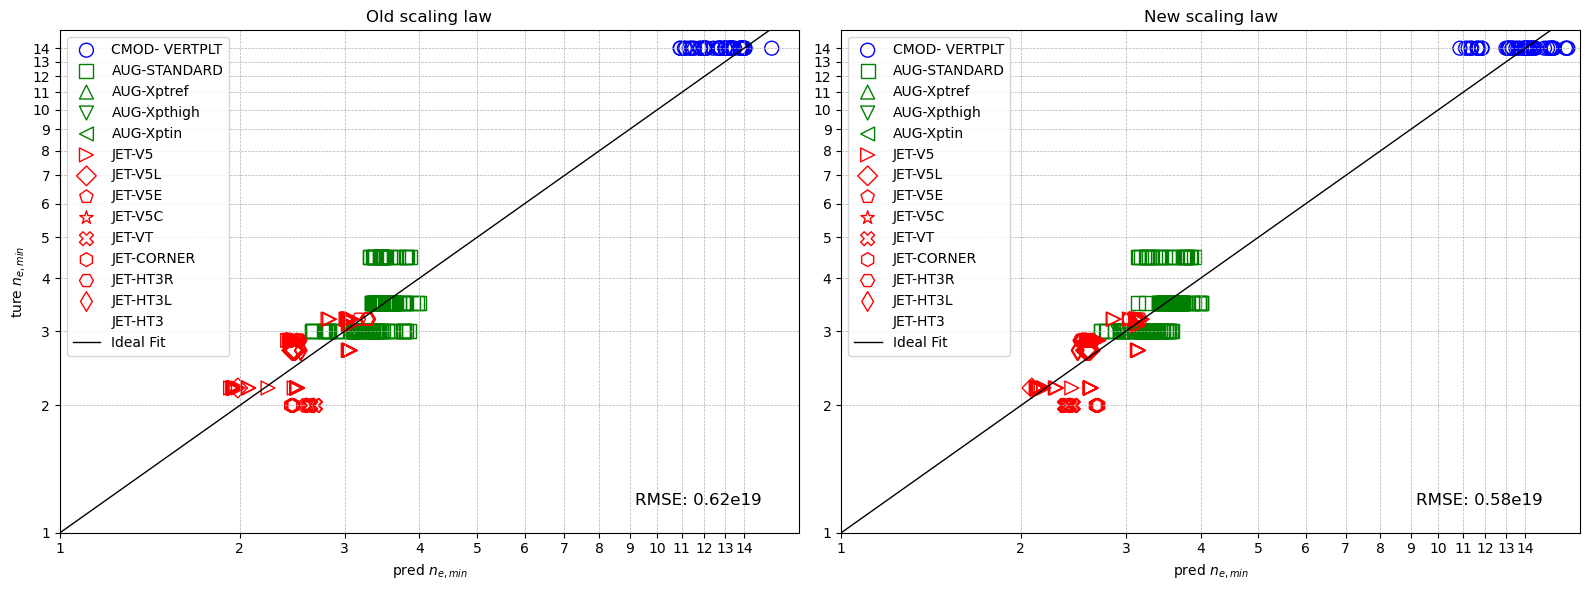

In [16]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter
import pandas as pd
import numpy as np
from itertools import cycle
from matplotlib import cm

# 假设 df 已经存在并包含以下列：IP, BT, AMIN, a, Nemin, TOK, DIVCON
# 定义公式和计算理想值
df['scaling_nemin_scal'] = 0.7 * (df['IP']**0.34) * (df['BT']**0.62) * (df['AMIN']**(-0.95)) * (df['a']**0.4)

# 自动获取唯一的 TOK 和 DIVCON 值
tok_values = df['TOK'].unique()
tok_unique = df['TOK'].unique()
divcon_values = df['DIVCON'].unique()
divcon_unique = df['DIVCON'].unique()
# 为 TOK 和 DIVCON 分配颜色和标记
color_map = {'CMOD': 'blue', 'AUG': 'green', 'JET': 'red'}
marker_styles = ['o', 's', '^', 'v', '<', '>', 'D', 'p', '*', 'X', 'h', 'H', 'd', '|']
marker_map = dict(zip(divcon_values, marker_styles[:len(divcon_values)]))


# 创建一行两列的图形
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 第一张图
for tok in tok_unique:
    for divcon in divcon_unique:
        sub_df = df[(df['TOK'] == tok) & (df['DIVCON'] == divcon)]
        if sub_df.empty:
            continue  # 跳过没有数据的组合
        ax1.scatter(
            sub_df['scaling_nemin_scal'],
            sub_df['Nemin'],
            facecolors='none',
            color=color_map[tok],
            marker=marker_map[divcon],
            label=f'{tok}-{divcon}',
            s=100
        )
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('pred $n_{e,min}$')
ax1.set_ylabel('ture $n_{e,min}$')
ax1.set_title('Old scaling law')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.xaxis.set_major_formatter(ScalarFormatter())
ax1.yaxis.set_major_formatter(ScalarFormatter())

# 设置 x 和 y 轴的范围
ax1.set_xlim(left=1)
ax1.set_ylim(bottom=1)
x_start, x_end = ax1.get_xlim()
y_start, y_end = ax1.get_ylim()
line_start = max(x_start, y_start)
line_end = min(x_end, y_end)
ax1.plot([line_start, line_end], [line_start, line_end],
         color='black', label='Ideal Fit', linewidth=1)

# 第二张图
for tok in tok_unique:
    for divcon in divcon_unique:
        sub_df = df[(df['TOK'] == tok) & (df['DIVCON'] == divcon)]
        if sub_df.empty:
            continue  # 跳过没有数据的组合
        ax2.scatter(
            sub_df['y_pred'],
            sub_df['y'],
            facecolors='none',
            color=color_map[tok],
            marker=marker_map[divcon],
            label=f'{tok}-{divcon}',
            s=100
        )
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('pred $n_{e,min}$')
#ax2.set_ylabel('Nemin')
ax2.set_title('New scaling law')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.xaxis.set_major_formatter(ScalarFormatter())
ax2.yaxis.set_major_formatter(ScalarFormatter())

# 设置 x 和 y 轴的范围
ax2.set_xlim(left=1)
ax2.set_ylim(bottom=1)

# 设置刻度
xmax1 = int(np.ceil(df['Nemin'].max()))
ymax1 = int(np.ceil(df['Nemin'].max()))
xticks1 = list(range(1, xmax1 + 1))
yticks1 = list(range(1, ymax1 + 1))

ax1.set_xticks(xticks1)
ax1.set_xticklabels([str(x) for x in xticks1])
ax1.set_yticks(yticks1)
ax1.set_yticklabels([str(y) for y in yticks1])
ax1.xaxis.set_major_formatter(FormatStrFormatter('%g'))
ax1.yaxis.set_major_formatter(FormatStrFormatter('%g'))
rmse1 = np.sqrt(((df['scaling_nemin_scal'] - df['Nemin']) ** 2).mean())
ax1.text(0.95, 0.05, f'RMSE: {rmse1:.2}e19', transform=ax1.transAxes,
         ha='right', va='bottom', fontsize=12, color='black')

# -------- 图2坐标设置 --------
xmax2 = int(np.ceil(np.exp(y_pred).max()))
ymax2 = int(np.ceil(np.exp(y_pred).max()))
xticks2 = list(range(1, xmax2 + 1))
yticks2 = list(range(1, ymax2 + 1))

ax2.set_xticks(xticks2)
ax2.set_xticklabels([str(x) for x in xticks2])
ax2.set_yticks(yticks2)
ax2.set_yticklabels([str(y) for y in yticks2])
ax2.xaxis.set_major_formatter(FormatStrFormatter('%g'))
ax2.yaxis.set_major_formatter(FormatStrFormatter('%g'))

# 画对角线：y = x，从 max(x_start, y_start) 到 min(x_end, y_end)
x_start, x_end = ax2.get_xlim()
y_start, y_end = ax2.get_ylim()
line_start = max(x_start, y_start)
line_end = min(x_end, y_end)
ax2.plot([line_start, line_end], [line_start, line_end],
         color='black', label='Ideal Fit', linewidth=1)

# 设定相同的坐标轴范围和刻度
ax2.set_xlim(ax1.get_xlim())
ax2.set_ylim(ax1.get_ylim())
ax2.set_xticks(ax1.get_xticks())
ax2.set_yticks(ax1.get_yticks())
ax2.set_xticklabels([str(x) for x in ax1.get_xticks()])
ax2.set_yticklabels([str(y) for y in ax1.get_yticks()])
ax2.text(0.95, 0.05, f'RMSE: {rmse:.2}e19', transform=ax2.transAxes,
         ha='right', va='bottom', fontsize=12, color='black')

# 显示图例
ax1.legend()
ax2.legend()

plt.tight_layout()
plt.show()


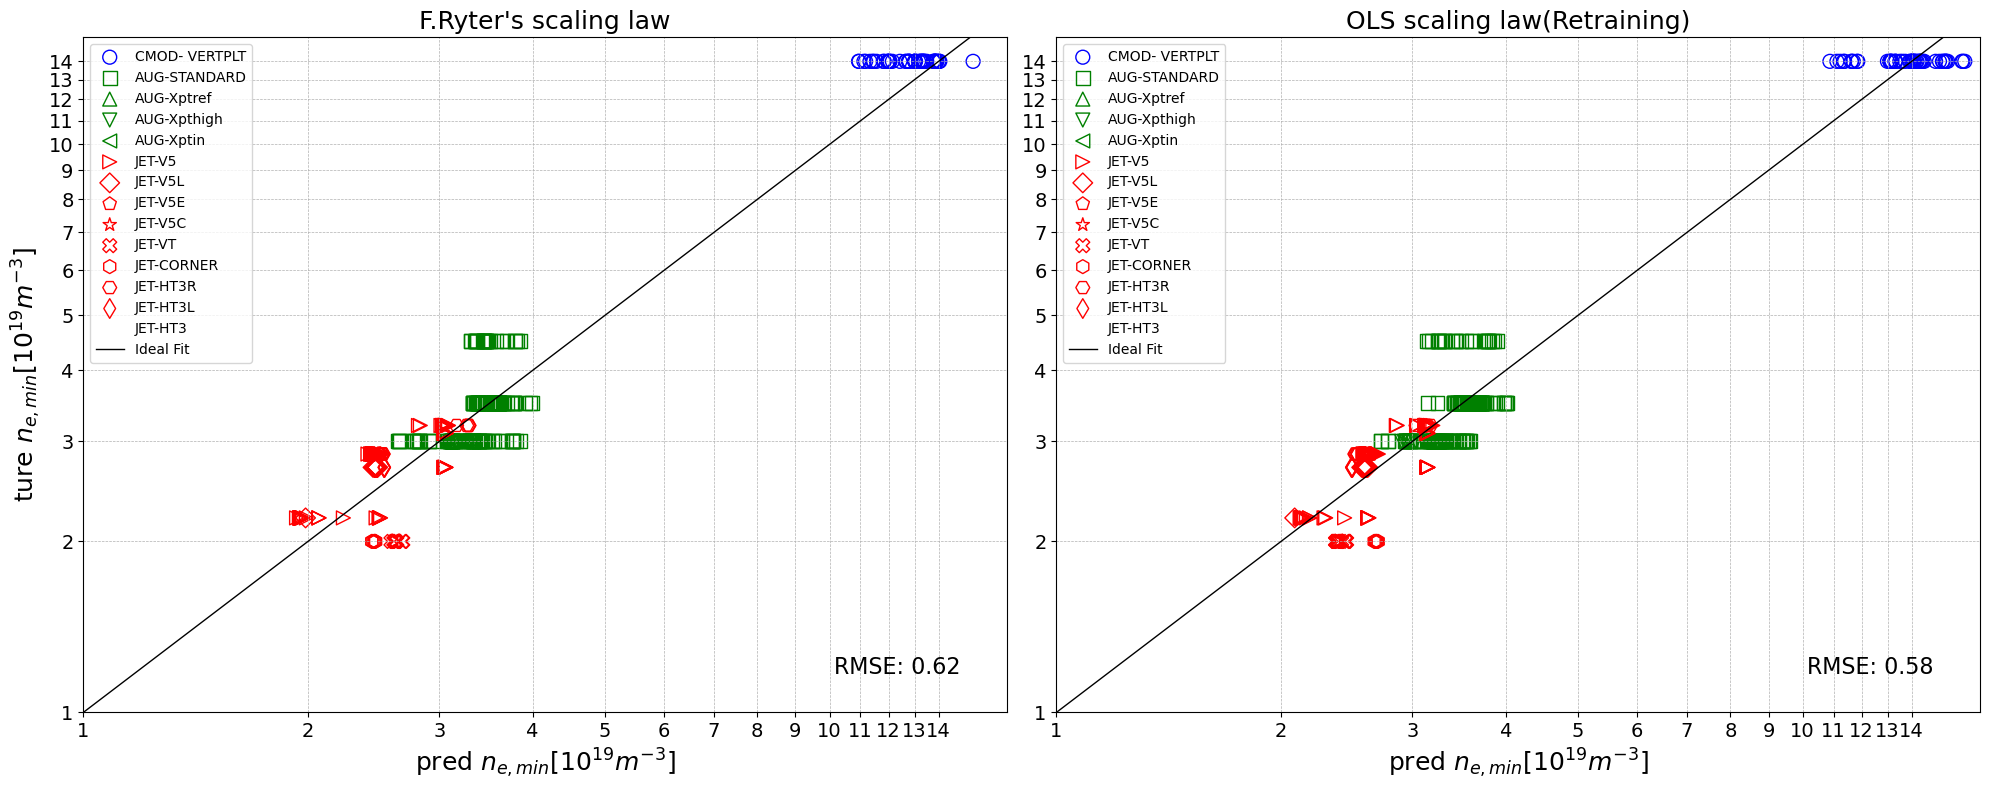

In [58]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter
import pandas as pd
import numpy as np
from itertools import cycle
from matplotlib import cm

# 假设 df 已经存在并包含以下列：IP, BT, AMIN, a, Nemin, TOK, DIVCON
# 定义公式和计算理想值
df['scaling_nemin_scal'] = 0.7 * (df['IP']**0.34) * (df['BT']**0.62) * (df['AMIN']**(-0.95)) * (df['a']**0.4)

# 自动获取唯一的 TOK 和 DIVCON 值
tok_values = df['TOK'].unique()
tok_unique = df['TOK'].unique()
divcon_values = df['DIVCON'].unique()
divcon_unique = df['DIVCON'].unique()
# 为 TOK 和 DIVCON 分配颜色和标记
color_map = {'CMOD': 'blue', 'AUG': 'green', 'JET': 'red'}
marker_styles = ['o', 's', '^', 'v', '<', '>', 'D', 'p', '*', 'X', 'h', 'H', 'd', '|']
marker_map = dict(zip(divcon_values, marker_styles[:len(divcon_values)]))


# 创建一行两列的图形
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# 第一张图
for tok in tok_unique:
    for divcon in divcon_unique:
        sub_df = df[(df['TOK'] == tok) & (df['DIVCON'] == divcon)]
        if sub_df.empty:
            continue  # 跳过没有数据的组合
        ax1.scatter(
            sub_df['scaling_nemin_scal'],
            sub_df['Nemin'],
            facecolors='none',
            color=color_map[tok],
            marker=marker_map[divcon],
            label=f'{tok}-{divcon}',
            s=100
        )
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('pred $n_{e,min}[10^{19}m^{-3}]$', fontsize=18)
ax1.set_ylabel('ture $n_{e,min}[10^{19}m^{-3}]$', fontsize=18)
ax1.set_title('F.Ryter\'s scaling law', fontsize=18)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.xaxis.set_major_formatter(ScalarFormatter())
ax1.yaxis.set_major_formatter(ScalarFormatter())

# 设置 x 和 y 轴的范围
ax1.set_xlim(left=1)
ax1.set_ylim(bottom=1)
x_start, x_end = ax1.get_xlim()
y_start, y_end = ax1.get_ylim()
line_start = max(x_start, y_start)
line_end = min(x_end, y_end)
ax1.plot([line_start, line_end], [line_start, line_end],
         color='black', label='Ideal Fit', linewidth=1)

# 第二张图
for tok in tok_unique:
    for divcon in divcon_unique:
        sub_df = df[(df['TOK'] == tok) & (df['DIVCON'] == divcon)]
        if sub_df.empty:
            continue  # 跳过没有数据的组合
        ax2.scatter(
            sub_df['y_pred'],
            sub_df['Nemin'],
            facecolors='none',
            color=color_map[tok],
            marker=marker_map[divcon],
            label=f'{tok}-{divcon}',
            s=100
        )
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('pred $n_{e,min}[10^{19}m^{-3}]$', fontsize=18)
#ax2.set_ylabel('Nemin')
ax2.set_title('OLS scaling law(Retraining)', fontsize=18)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.xaxis.set_major_formatter(ScalarFormatter())
ax2.yaxis.set_major_formatter(ScalarFormatter())

# 设置 x 和 y 轴的范围
ax2.set_xlim(left=1)
ax2.set_ylim(bottom=1)

# 设置刻度
xmax1 = int(np.ceil(df['Nemin'].max()))
ymax1 = int(np.ceil(df['Nemin'].max()))
xticks1 = list(range(1, xmax1 + 1))
yticks1 = list(range(1, ymax1 + 1))

ax1.set_xticks(xticks1)
ax1.set_xticklabels([str(x) for x in xticks1], fontsize=14)
ax1.set_yticks(yticks1)
ax1.set_yticklabels([str(y) for y in yticks1], fontsize=14)
ax1.xaxis.set_major_formatter(FormatStrFormatter('%g'))
ax1.yaxis.set_major_formatter(FormatStrFormatter('%g'))
rmse1 = np.sqrt(((df['scaling_nemin_scal'] - df['Nemin']) ** 2).mean())
ax1.text(0.95, 0.05, f'RMSE: {rmse1:.2}', transform=ax1.transAxes,
         ha='right', va='bottom', fontsize=16, color='black')

# -------- 图2坐标设置 --------
xmax2 = int(np.ceil(np.exp(y_pred).max()))
ymax2 = int(np.ceil(np.exp(y_pred).max()))
xticks2 = list(range(1, xmax2 + 1))
yticks2 = list(range(1, ymax2 + 1))

ax2.set_xticks(xticks2)
ax2.set_xticklabels([str(x) for x in xticks2])
ax2.set_yticks(yticks2)
ax2.set_yticklabels([str(y) for y in yticks2])
ax2.xaxis.set_major_formatter(FormatStrFormatter('%g'))
ax2.yaxis.set_major_formatter(FormatStrFormatter('%g'))

# 画对角线：y = x，从 max(x_start, y_start) 到 min(x_end, y_end)
x_start, x_end = ax2.get_xlim()
y_start, y_end = ax2.get_ylim()
line_start = max(x_start, y_start)
line_end = min(x_end, y_end)
ax2.plot([line_start, line_end], [line_start, line_end],
         color='black', label='Ideal Fit', linewidth=1)

# 设定相同的坐标轴范围和刻度
ax2.set_xlim(ax1.get_xlim())
ax2.set_ylim(ax1.get_ylim())
ax2.set_xticks(ax1.get_xticks())
ax2.set_yticks(ax1.get_yticks())
ax2.set_xticklabels([str(x) for x in ax1.get_xticks()], fontsize=14)
ax2.set_yticklabels([str(y) for y in ax1.get_yticks()], fontsize=14)
rmse2 = np.sqrt(((df['y_pred'] - df['Nemin']) ** 2).mean())
ax2.text(0.95, 0.05, f'RMSE: {rmse2:.2}', transform=ax2.transAxes,
         ha='right', va='bottom', fontsize=16, color='black')

# 显示图例
ax1.legend()
ax2.legend()

plt.tight_layout()
plt.savefig('compare_nemin_new_result.png', format='png', dpi=600, transparent=True)
plt.show()



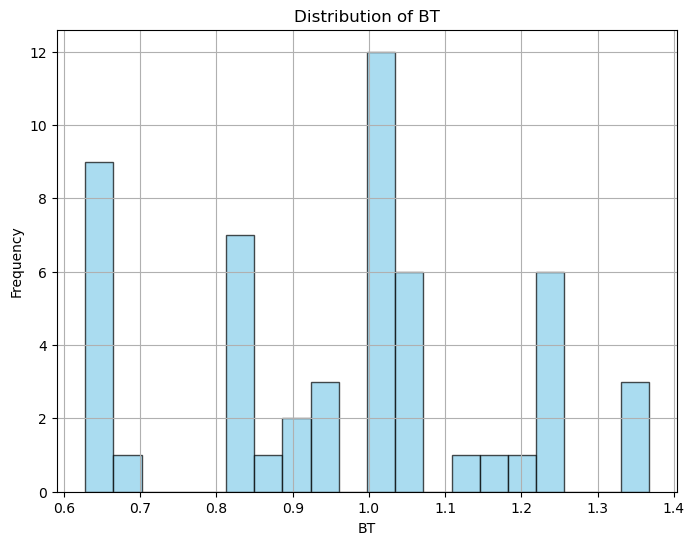

In [153]:
'''import matplotlib.pyplot as plt

# 使用matplotlib绘制直方图
plt.figure(figsize=(8, 6))
plt.hist(subset1['IP'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of BT')
plt.xlabel('BT')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()
'''

In [431]:

import statsmodels.api as sm

# 指定你想在新 DataFrame 中包含的列
columns_to_include = ['TOK','Nemin', 'SPLASMA','BT','IP','a','AMIN','RGEO','PLTH','NEL','PGASA',"DIVCON"]
new_df = df[columns_to_include].copy()
mu0 = 4 * np.pi * 1e-7

new_df['BP']=1000000*(mu0 * new_df['IP']) / (new_df['SPLASMA']/(2 * np.pi * new_df['RGEO']))

new_df['PLTH/S/2']=new_df['PLTH']/(new_df['SPLASMA']*2)



columns_to_include_for_regre = ['Nemin','BP','SPLASMA','PGASA','IP','BT','AMIN','a']
unique_divcon = new_df['DIVCON'].unique()

# 2. 向原始 DataFrame 添加新列
for divcon_type in unique_divcon:
    new_df[divcon_type] = (new_df['DIVCON'] == divcon_type).astype(int)
multi_df = new_df[columns_to_include_for_regre].copy()
multi_df = multi_df.apply(np.log)
x = multi_df[['IP','PGASA','BT','AMIN','a']] 
x[unique_divcon] = new_df[unique_divcon]
x['Xp'] = x[['Xptref','Xpthigh','Xptin']].max(axis=1)
x.drop(['STANDARD'], axis=1, inplace=True)
x.drop(['Xptref','Xpthigh','Xptin'], axis=1, inplace=True)
x['V5'] = x[['V5E','V5C','V5']].max(axis=1)
x.drop(['V5E','V5C'], axis=1, inplace=True)
x['HT3'] = x[['HT3R','HT3L','HT3']].max(axis=1)
x.drop(['HT3R','HT3L'], axis=1, inplace=True)
X_with_intercept = sm.add_constant(x)
y=multi_df["Nemin"]
model = sm.OLS(y, X_with_intercept)
results = model.fit()

# 打印详细统计结果
print(results.summary())

# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")
    # 打印 RMSE
y_pred = results.predict(X_with_intercept)  # 预测值
rmse = np.sqrt(np.mean((np.exp(y) - np.exp(y_pred)) ** 2))  # 计算 RMSE

print(f"RMSE: {rmse:.3f}")
# 获取 90% 置信区间
conf_int_90 = results.conf_int(alpha=0.1)


print("\n90% 置信区间：\n", conf_int_90)
new_df[columns_to_include_for_regre]

                            OLS Regression Results                            
Dep. Variable:                  Nemin   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     4535.
Date:                Wed, 30 Apr 2025   Prob (F-statistic):               0.00
Time:                        12:01:45   Log-Likelihood:                 795.53
No. Observations:                 486   AIC:                            -1565.
Df Residuals:                     473   BIC:                            -1511.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8593      0.281      3.061      0.0

,Nemin,PGASA,IP,BT,AMIN,a
0,14.0,2.000,0.931812,5.33923,0.216421,3.106857
1,14.0,2.000,0.655357,5.35375,0.217660,3.081747
2,14.0,2.000,0.634247,5.32586,0.217388,3.094858
3,14.0,2.000,1.030660,5.33346,0.217080,3.090423
4,14.0,2.000,0.681653,5.26510,0.213690,3.176396
...,...,...,...,...,...,...
663,3.2,1.972,2.470630,2.97606,0.928461,3.111989
664,3.2,1.979,2.715140,2.97667,0.924404,3.128751
665,3.2,1.972,2.716620,2.97529,0.925206,3.125769
666,3.2,1.991,2.721300,2.97753,0.926219,3.120903


In [36]:
import pymc as pm
import numpy as np
import arviz as az


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [alpha, p, eta, beta_ori, beta_m, pi, sigma2]
>CategoricalGibbsMetropolis: [S]
>BinaryGibbsMetropolis: [gamma_prev, gamma]


Output()

Sampling 4 chains for 500 tune and 3_000 draw iterations (2_000 + 12_000 draws total) took 624 seconds.
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 1359 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.0800

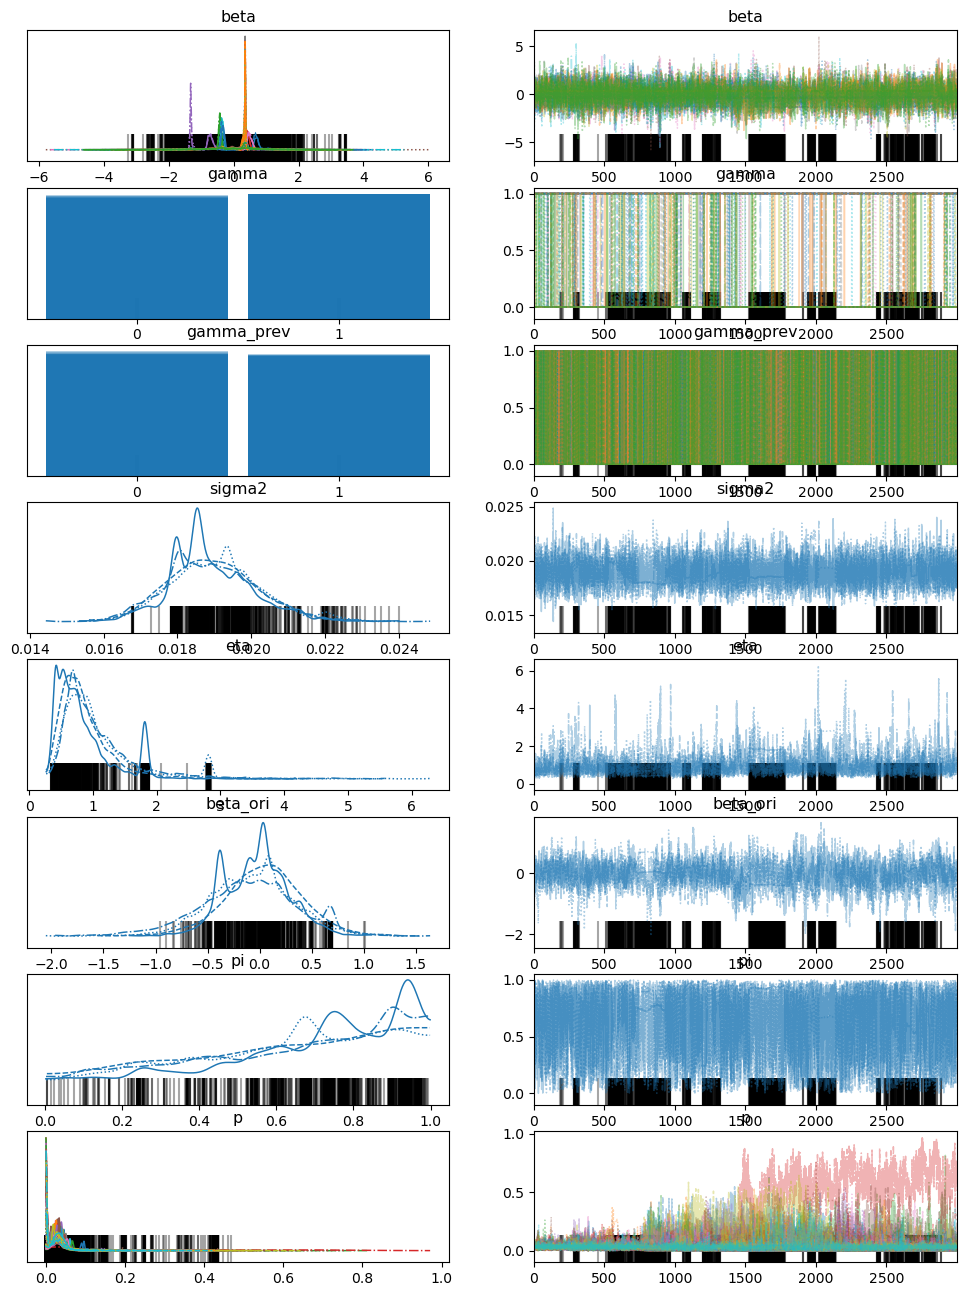

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]  0.591  0.309   0.258    1.163      0.097    0.070       8.0   
beta[1]  0.337  0.044   0.241    0.413      0.002    0.002     396.0   
beta[2] -0.421  0.038  -0.491   -0.349      0.006    0.004      46.0   
beta[3]  0.386  0.056   0.302    0.506      0.010    0.007      41.0   
beta[4] -1.016  0.308  -1.375   -0.604      0.151    0.116       6.0   
...        ...    ...     ...      ...        ...      ...       ...   
p[25]    0.026  0.023   0.000    0.059      0.004    0.003      17.0   
p[26]    0.030  0.029   0.000    0.068      0.004    0.003      17.0   
p[27]    0.025  0.024   0.000    0.062      0.004    0.003      13.0   
p[28]    0.031  0.034   0.000    0.077      0.007    0.005      12.0   
p[29]    0.029  0.031   0.000    0.065      0.005    0.004      14.0   

         ess_tail  r_hat  
beta[0]      44.0   1.42  
beta[1]     208.0   1.16  
beta[2]     178.0   1.05  
beta[3]     403.0   1.12  


In [437]:

# Step 1: Generate simulated data
np.random.seed(42)
N = 3000  # Number of samples
D = 13  # Number of predictors


# Step 2: Define the PyMC model
with pm.Model() as model:
    # Priors
    # Beta for regression coefficients, grouped into classes
    alpha = pm.HalfNormal("alpha", sigma=8.0)  # Dirichlet prior concentration parameter
    #alpha=1
    p = pm.Dirichlet("p", a=pm.math.ones(30) * alpha, shape=30)  # Class probabilities
 #10 0 1 2 3 4 
    S = pm.Categorical("S", p=p, shape=D)# bp=nel shape  1 1 1  # Class assignment for predictors (0-9)
    #[1 3 5 7 9]
    eta = pm.InverseGamma("eta", alpha=4, beta=4)  # Variance for beta_m
    mu_0=pm.Normal("beta_ori",mu=0,sigma=1)
    beta_m = pm.Normal("beta_m", mu=mu_0, sigma=pm.math.sqrt(eta), shape=30)  # Regression coefficients for each class
    
    # Ensure S only indexes valid categories of beta_m
    beta = pm.Deterministic("beta", beta_m[S])  # Map beta based on S
    
    # Sparsity indicator gamma
    pi = pm.Beta("pi", alpha=1, beta=1)  # Probability of gamma=1
    gamma_prev = pm.Bernoulli("gamma_prev", p=0.5, shape=D)  # 初始值
    rho = 0.8  # 控制gamma的平稳性（越接近1越稳定）
    gamma = pm.Bernoulli("gamma", p=rho * gamma_prev + (1 - rho) * pi, shape=D)

    #gamma = pm.Bernoulli("gamma", p=pi, shape=D)

    # Noise variance (sigma^2)
    sigma2 = pm.InverseGamma("sigma2", alpha=4, beta=4)  # Prior for noise variance

    # Observed data likelihood
    mu = pm.math.dot(X_with_intercept, beta * gamma)  # Predicted mean
    y_obs = pm.Normal("y_obs", mu=mu, sigma=pm.math.sqrt(sigma2), observed=y)

    # Inference
    
    trace = pm.sample(N, tune=500, chains=4,step=pm.NUTS(target_accept=0.95), return_inferencedata=True)


# Step 3: Analyze and visualize the results
az.plot_trace(trace, var_names=["beta", "gamma", "gamma_prev","sigma2", "eta", "beta_ori","pi", "p"])
plt.show()
summary=az.summary(trace, var_names=["beta", "gamma","gamma_prev", "sigma2", "eta","beta_ori", "pi", "p"])
print(summary)

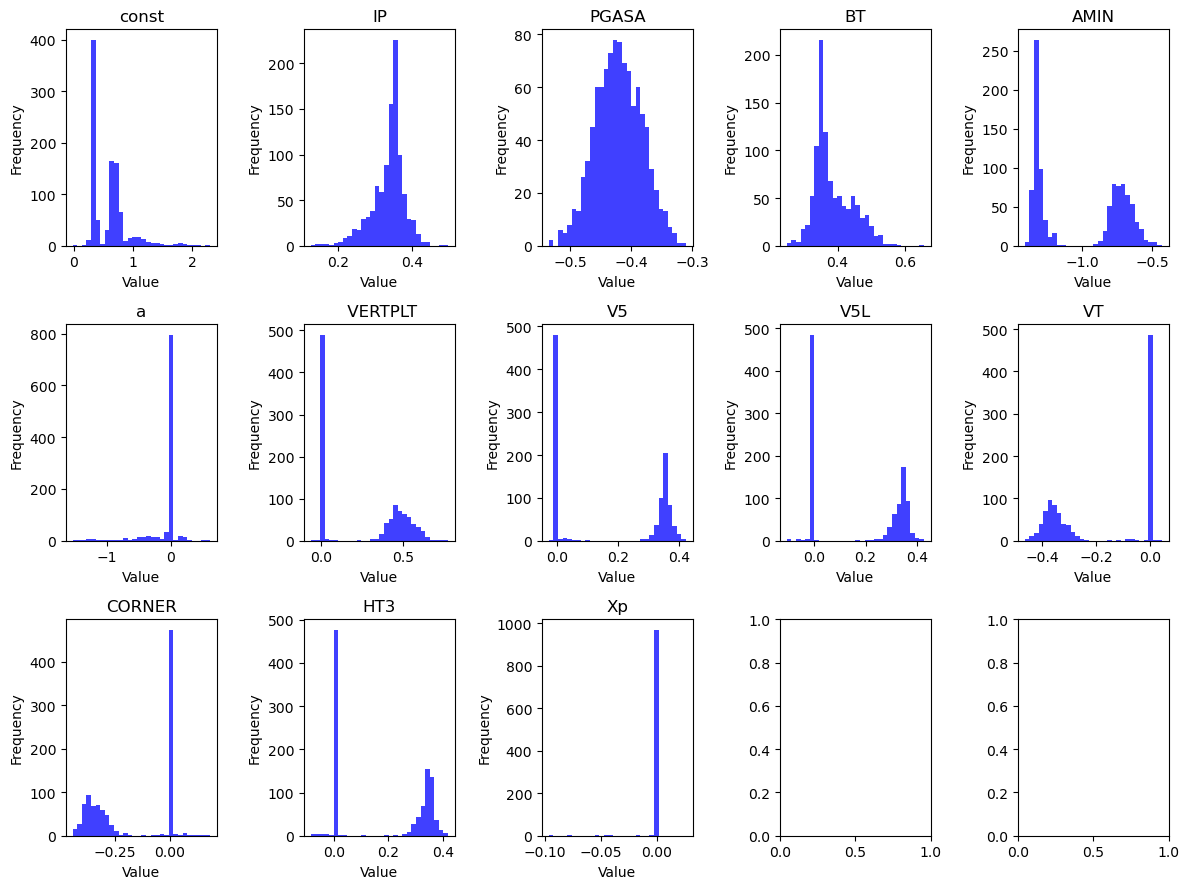

[1.    1.    1.    1.    1.    0.215 0.513 0.522 0.518 0.516 0.528 0.525
 0.03 ]
[ 0.5900941   0.33503637 -0.42092527  0.38555824 -1.01533748 -0.06649626
  0.24674539  0.17829659  0.16832959 -0.17842661 -0.168339    0.17037679
 -0.00117189]
[10.987 13.639 14.025 11.727 15.305 13.212 13.189 13.726 13.917 15.39
 14.828 13.158 13.76 ]
1000 samples' R² values=: 0.9905


In [438]:
# 从后验中随机抽取 10 个样本
num_samples = 1000
posterior_indices = np.random.choice(
    trace.posterior["beta"].stack(samples=["chain", "draw"]).shape[1], 
    size=num_samples, 
    replace=False
)

# 定义新数据
 # 新数据 (10 个样本)

# 存储预测结果
beta_new_look = []
predictions = []
S_new = []
gamma_new=[]
for idx in posterior_indices:
    beta_sample = trace.posterior["beta"].stack(samples=["chain", "draw"]).values[:, idx]
    gamma_sample = trace.posterior["gamma"].stack(samples=["chain", "draw"]).values[:, idx]
    S_sample = trace.posterior["S"].stack(samples=["chain", "draw"]).values[:, idx]
    sigma_sample = np.sqrt(trace.posterior["sigma2"].stack(samples=["chain", "draw"]).values[idx])
    #gamma_binary = (gamma_post_mean > 0.5).astype(int)
    # 计算预测值
    mu_pred = X_with_intercept @ (beta_sample * gamma_sample)  # 预测均值
    y_pred = np.random.normal(mu_pred, sigma_sample, size=X_with_intercept.shape[0])  # 从预测分布采样
    S_new.append(gamma_sample*beta_sample)
    beta_new_look.append(S_sample)
    gamma_new.append(gamma_sample)
    predictions.append(y_pred)
S_new1 = np.array(S_new)
gamma_new = np.array(gamma_new)
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(12, 9))
axes = axes.flatten()

for i in range(13):
    ax = axes[i]
    # 只考虑 gamma 为 1 的情况
    #filtered_beta = S_new1[:, i][gamma_new[:, i] == 1]
    filtered_beta = S_new1[:, i]
    ax.hist(filtered_beta, bins=30, alpha=0.75, color='blue')
    ax.set_title(f'{X_with_intercept.columns[i]}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distribution.png', format='png', dpi=300, transparent=True)
plt.show()
S_mean_new = np.array(S_new).mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)
print(gamma_mean)

predictions = np.array(predictions).T  
pred_mean = predictions.mean(axis=1) 
print(S_mean_new)
print(beta_new_look_new)
SS_res = np.sum((pred_mean - y) ** 2)
SS_tot = np.sum((y - np.mean(y)) ** 2)
R_squared = 1 - (SS_res / SS_tot)
print(f"1000 samples' R² values=: {R_squared:.4f}")

In [439]:

trace.to_netcdf("nemin_trace.nc")

# 查看并保存summary
summary_df = az.summary(trace, var_names=["beta", "gamma","gamma_prev", "sigma2", "beta_ori","eta", "pi", "p"])
print(summary_df)
summary_df.to_csv("nemin_trace.csv")

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]  0.591  0.309   0.258    1.163      0.097    0.070       8.0   
beta[1]  0.337  0.044   0.241    0.413      0.002    0.002     396.0   
beta[2] -0.421  0.038  -0.491   -0.349      0.006    0.004      46.0   
beta[3]  0.386  0.056   0.302    0.506      0.010    0.007      41.0   
beta[4] -1.016  0.308  -1.375   -0.604      0.151    0.116       6.0   
...        ...    ...     ...      ...        ...      ...       ...   
p[25]    0.026  0.023   0.000    0.059      0.004    0.003      17.0   
p[26]    0.030  0.029   0.000    0.068      0.004    0.003      17.0   
p[27]    0.025  0.024   0.000    0.062      0.004    0.003      13.0   
p[28]    0.031  0.034   0.000    0.077      0.007    0.005      12.0   
p[29]    0.029  0.031   0.000    0.065      0.005    0.004      14.0   

         ess_tail  r_hat  
beta[0]      44.0   1.42  
beta[1]     208.0   1.16  
beta[2]     178.0   1.05  
beta[3]     403.0   1.12  


In [452]:

import statsmodels.api as sm

# 指定你想在新 DataFrame 中包含的列
columns_to_include = ['TOK','Nemin', 'SPLASMA','BT','IP','a','AMIN','RGEO','PLTH','NEL','PGASA',"DIVCON",'Q95','KAPPA']
new_df = df[columns_to_include].copy()
mu0 = 4 * np.pi * 1e-7

new_df['BP']=1000000*(mu0 * new_df['IP']) / (new_df['SPLASMA']/(2 * np.pi * new_df['RGEO']))





columns_to_include_for_regre = ['Nemin','BP','SPLASMA','PGASA','IP','BT','AMIN','a','Q95','KAPPA']
unique_divcon = new_df['DIVCON'].unique()

# 2. 向原始 DataFrame 添加新列
for divcon_type in unique_divcon:
    new_df[divcon_type] = (new_df['DIVCON'] == divcon_type).astype(int)
multi_df = new_df[columns_to_include_for_regre].copy()
multi_df = multi_df.apply(np.log)
x = multi_df[['IP','SPLASMA','PGASA','BT']] 
x[unique_divcon] = new_df[unique_divcon]
x['Xp'] = x[['Xptref','Xpthigh','Xptin']].max(axis=1)
x.drop(['STANDARD'], axis=1, inplace=True)
x.drop(['Xptref','Xpthigh','Xptin'], axis=1, inplace=True)
x['V5'] = x[['V5E','V5C','V5']].max(axis=1)
x.drop(['V5E','V5C'], axis=1, inplace=True)
x['HT3'] = x[['HT3R','HT3L','HT3']].max(axis=1)
x.drop(['HT3R','HT3L'], axis=1, inplace=True)
X_with_intercept = sm.add_constant(x)
y=multi_df["Nemin"]
model = sm.OLS(y, X_with_intercept)
results = model.fit()

# 打印详细统计结果
print(results.summary())

# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")
    # 打印 RMSE
y_pred = results.predict(X_with_intercept)  # 预测值
rmse = np.sqrt(np.mean((np.exp(y) - np.exp(y_pred)) ** 2))  # 计算 RMSE

print(f"RMSE: {rmse:.3f}")
# 获取 90% 置信区间
conf_int_90 = results.conf_int(alpha=0.1)


print("\n90% 置信区间：\n", conf_int_90)
new_df[columns_to_include_for_regre]

                            OLS Regression Results                            
Dep. Variable:                  Nemin   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     4960.
Date:                Wed, 30 Apr 2025   Prob (F-statistic):               0.00
Time:                        15:14:04   Log-Likelihood:                 795.62
No. Observations:                 486   AIC:                            -1567.
Df Residuals:                     474   BIC:                            -1517.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1454      0.700      3.067      0.0

/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_26559/169280527.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[unique_divcon] = new_df[unique_divcon]
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_26559/169280527.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[unique_divcon] = new_df[unique_divcon]
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_26559/169280527.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


,Nemin,BP,SPLASMA,PGASA,IP,BT,AMIN,a,Q95,KAPPA
0,14.0,0.666565,7.42158,2.000,0.931812,5.33923,0.216421,3.106857,4.26029,1.69737
1,14.0,0.470971,7.36968,2.000,0.655357,5.35375,0.217660,3.081747,5.89660,1.67073
2,14.0,0.456655,7.37796,2.000,0.634247,5.32586,0.217388,3.094858,6.19549,1.67962
3,14.0,0.734135,7.43647,2.000,1.030660,5.33346,0.217080,3.090423,3.86097,1.69789
4,14.0,0.544822,6.70529,2.000,0.681653,5.26510,0.213690,3.176396,4.40365,1.44202
...,...,...,...,...,...,...,...,...,...,...
663,3.2,0.410025,137.46400,1.972,2.470630,2.97606,0.928461,3.111989,3.71799,1.68223
664,3.2,0.451442,137.34500,1.979,2.715140,2.97667,0.924404,3.128751,3.36799,1.68578
665,3.2,0.451495,137.39200,1.972,2.716620,2.97529,0.925206,3.125769,3.37939,1.68724
666,3.2,0.451793,137.47400,1.991,2.721300,2.97753,0.926219,3.120903,3.37763,1.68593


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [alpha, p, eta, beta_ori, beta_m, pi, sigma2]
>CategoricalGibbsMetropolis: [S]
>BinaryGibbsMetropolis: [gamma_prev, gamma]


Output()

Sampling 4 chains for 500 tune and 3_000 draw iterations (2_000 + 12_000 draws total) took 648 seconds.
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 4115 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is

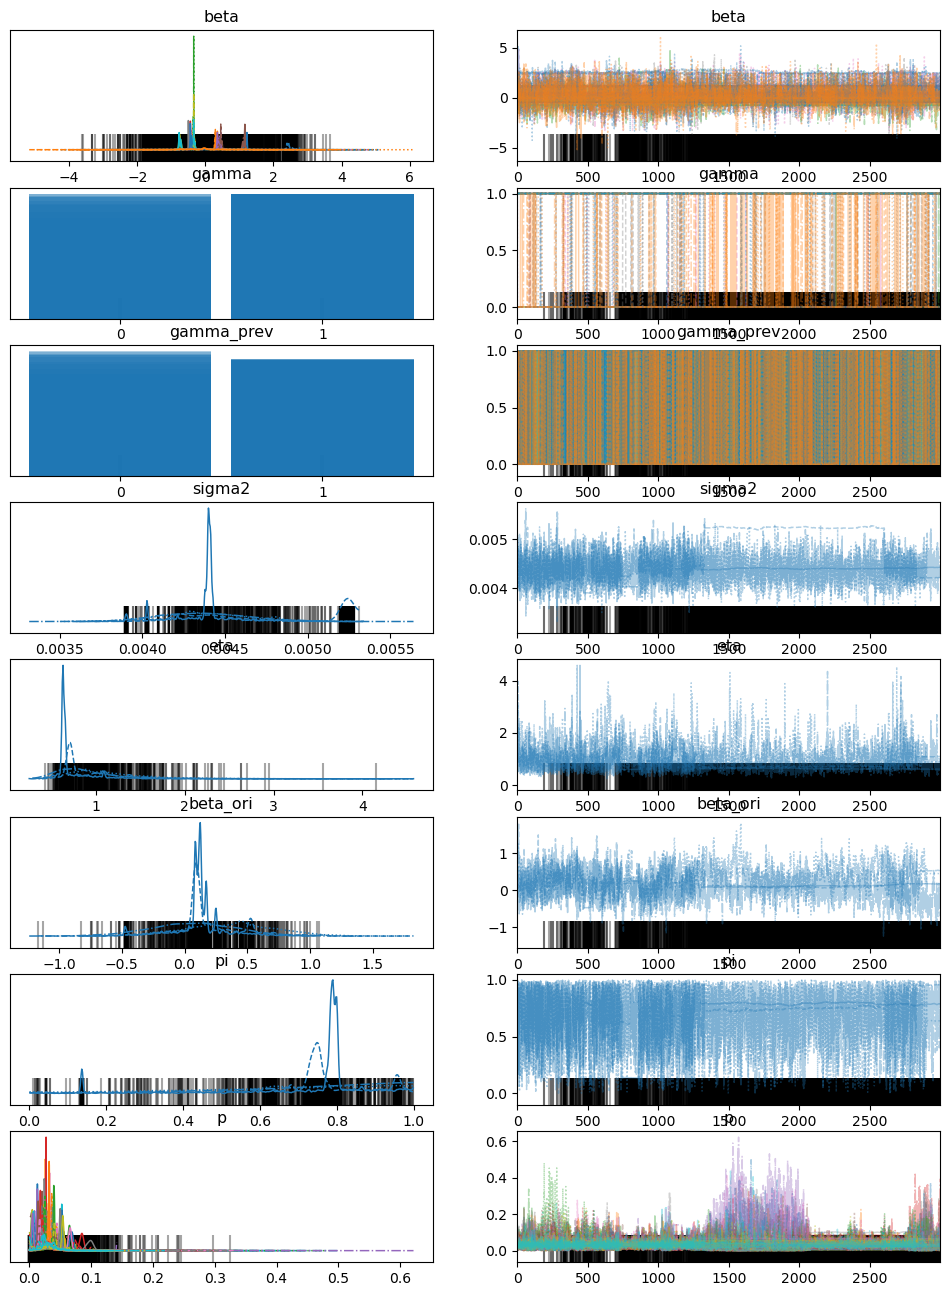

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]  1.833  0.669   1.071    2.681      0.332    0.254       5.0   
beta[1]  0.318  0.031   0.264    0.375      0.008    0.006      16.0   
beta[2] -0.143  0.623  -0.976    1.266      0.106    0.081     121.0   
beta[3] -0.427  0.019  -0.459   -0.392      0.003    0.002      59.0   
beta[4]  0.408  0.038   0.338    0.467      0.013    0.010       9.0   
...        ...    ...     ...      ...        ...      ...       ...   
p[25]    0.031  0.021   0.000    0.057      0.004    0.003      23.0   
p[26]    0.036  0.024   0.002    0.069      0.006    0.004      14.0   
p[27]    0.035  0.021   0.000    0.062      0.004    0.003      21.0   
p[28]    0.036  0.018   0.000    0.057      0.004    0.003      14.0   
p[29]    0.029  0.017   0.000    0.054      0.002    0.001      60.0   

         ess_tail  r_hat  
beta[0]      24.0   2.02  
beta[1]      40.0   1.17  
beta[2]      76.0   1.81  
beta[3]     246.0   1.06  


In [453]:

# Step 1: Generate simulated data
np.random.seed(42)
N = 3000  # Number of samples
D = 12  # Number of predictors


# Step 2: Define the PyMC model
with pm.Model() as model:
    # Priors
    # Beta for regression coefficients, grouped into classes
    alpha = pm.HalfNormal("alpha", sigma=8.0)  # Dirichlet prior concentration parameter
    #alpha=1
    p = pm.Dirichlet("p", a=pm.math.ones(30) * alpha, shape=30)  # Class probabilities
 #10 0 1 2 3 4 
    S = pm.Categorical("S", p=p, shape=D)# bp=nel shape  1 1 1  # Class assignment for predictors (0-9)
    #[1 3 5 7 9]
    eta = pm.InverseGamma("eta", alpha=4, beta=4)  # Variance for beta_m
    mu_0=pm.Normal("beta_ori",mu=0,sigma=1)
    beta_m = pm.Normal("beta_m", mu=mu_0, sigma=pm.math.sqrt(eta), shape=30)  # Regression coefficients for each class
    
    # Ensure S only indexes valid categories of beta_m
    beta = pm.Deterministic("beta", beta_m[S])  # Map beta based on S
    
    # Sparsity indicator gamma
    pi = pm.Beta("pi", alpha=1, beta=1)  # Probability of gamma=1
    gamma_prev = pm.Bernoulli("gamma_prev", p=0.5, shape=D)  # 初始值
    rho = 0.8  # 控制gamma的平稳性（越接近1越稳定）
    gamma = pm.Bernoulli("gamma", p=rho * gamma_prev + (1 - rho) * pi, shape=D)

    #gamma = pm.Bernoulli("gamma", p=pi, shape=D)

    # Noise variance (sigma^2)
    sigma2 = pm.InverseGamma("sigma2", alpha=4, beta=0.5)  # Prior for noise variance

    # Observed data likelihood
    mu = pm.math.dot(X_with_intercept, beta * gamma)  # Predicted mean
    y_obs = pm.Normal("y_obs", mu=mu, sigma=pm.math.sqrt(sigma2), observed=y)

    # Inference
    
    trace = pm.sample(N, tune=500, chains=4,step=pm.NUTS(target_accept=0.95), return_inferencedata=True)


# Step 3: Analyze and visualize the results
az.plot_trace(trace, var_names=["beta", "gamma", "gamma_prev","sigma2", "eta", "beta_ori","pi", "p"])
plt.show()
summary=az.summary(trace, var_names=["beta", "gamma","gamma_prev", "sigma2", "eta","beta_ori", "pi", "p"])
print(summary)

IndexError: index 12 is out of bounds for axis 1 with size 12

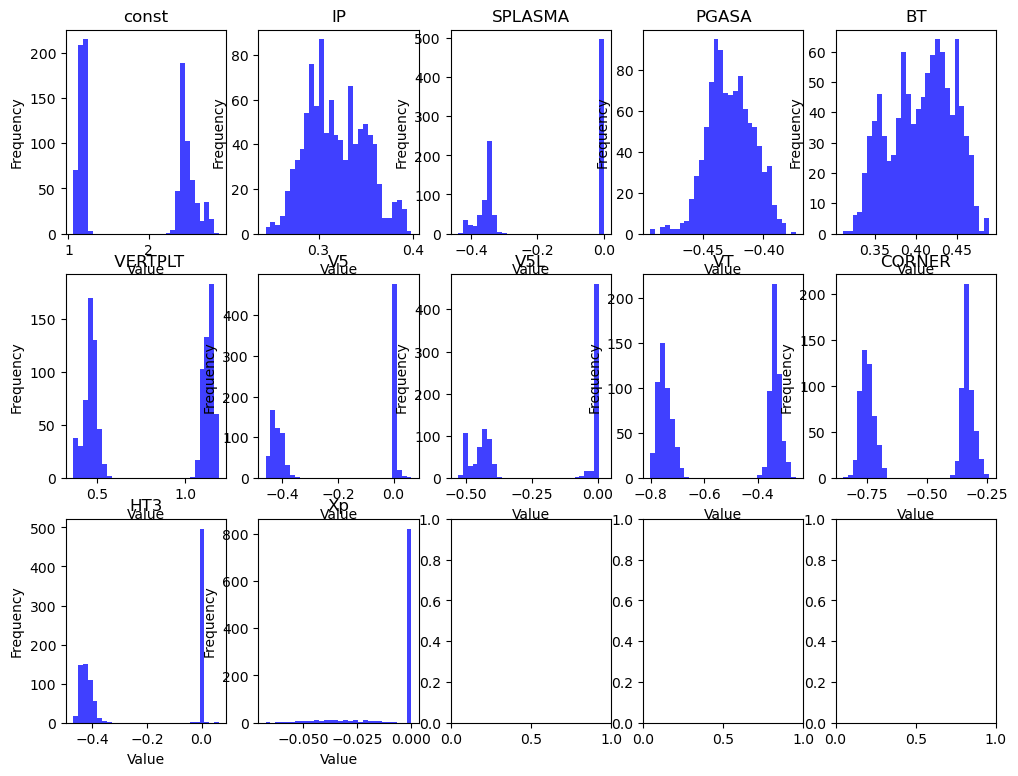

In [454]:
# 从后验中随机抽取 10 个样本
num_samples = 1000
posterior_indices = np.random.choice(
    trace.posterior["beta"].stack(samples=["chain", "draw"]).shape[1], 
    size=num_samples, 
    replace=False
)

# 定义新数据
 # 新数据 (10 个样本)

# 存储预测结果
beta_new_look = []
predictions = []
S_new = []
gamma_new=[]
for idx in posterior_indices:
    beta_sample = trace.posterior["beta"].stack(samples=["chain", "draw"]).values[:, idx]
    gamma_sample = trace.posterior["gamma"].stack(samples=["chain", "draw"]).values[:, idx]
    S_sample = trace.posterior["S"].stack(samples=["chain", "draw"]).values[:, idx]
    sigma_sample = np.sqrt(trace.posterior["sigma2"].stack(samples=["chain", "draw"]).values[idx])
    #gamma_binary = (gamma_post_mean > 0.5).astype(int)
    # 计算预测值
    mu_pred = X_with_intercept @ (beta_sample * gamma_sample)  # 预测均值
    y_pred = np.random.normal(mu_pred, sigma_sample, size=X_with_intercept.shape[0])  # 从预测分布采样
    S_new.append(gamma_sample*beta_sample)
    beta_new_look.append(S_sample)
    gamma_new.append(gamma_sample)
    predictions.append(y_pred)
S_new1 = np.array(S_new)
gamma_new = np.array(gamma_new)
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(12, 9))
axes = axes.flatten()

for i in range(13):
    ax = axes[i]
    # 只考虑 gamma 为 1 的情况
    #filtered_beta = S_new1[:, i][gamma_new[:, i] == 1]
    filtered_beta = S_new1[:, i]
    ax.hist(filtered_beta, bins=30, alpha=0.75, color='blue')
    ax.set_title(f'{X_with_intercept.columns[i]}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distribution.png', format='png', dpi=300, transparent=True)
plt.show()
S_mean_new = np.array(S_new).mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)
print(gamma_mean)

predictions = np.array(predictions).T  
pred_mean = predictions.mean(axis=1) 
print(S_mean_new)
print(beta_new_look_new)
SS_res = np.sum((pred_mean - y) ** 2)
SS_tot = np.sum((y - np.mean(y)) ** 2)
R_squared = 1 - (SS_res / SS_tot)
print(f"1000 samples' R² values=: {R_squared:.4f}")

In [455]:

trace.to_netcdf("SPLASMA_nemin_trace.nc")

# 查看并保存summary
summary_df = az.summary(trace, var_names=["beta", "gamma","gamma_prev", "sigma2", "beta_ori","eta", "pi", "p"])
print(summary_df)
summary_df.to_csv("SPLASMA_nemin_trace.csv")

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]  1.833  0.669   1.071    2.681      0.332    0.254       5.0   
beta[1]  0.318  0.031   0.264    0.375      0.008    0.006      16.0   
beta[2] -0.143  0.623  -0.976    1.266      0.106    0.081     121.0   
beta[3] -0.427  0.019  -0.459   -0.392      0.003    0.002      59.0   
beta[4]  0.408  0.038   0.338    0.467      0.013    0.010       9.0   
...        ...    ...     ...      ...        ...      ...       ...   
p[25]    0.031  0.021   0.000    0.057      0.004    0.003      23.0   
p[26]    0.036  0.024   0.002    0.069      0.006    0.004      14.0   
p[27]    0.035  0.021   0.000    0.062      0.004    0.003      21.0   
p[28]    0.036  0.018   0.000    0.057      0.004    0.003      14.0   
p[29]    0.029  0.017   0.000    0.054      0.002    0.001      60.0   

         ess_tail  r_hat  
beta[0]      24.0   2.02  
beta[1]      40.0   1.17  
beta[2]      76.0   1.81  
beta[3]     246.0   1.06  


In [484]:

import statsmodels.api as sm

# 指定你想在新 DataFrame 中包含的列
columns_to_include = ['TOK','Nemin', 'SPLASMA','BT','IP','a','AMIN','RGEO','PLTH','NEL','PGASA',"DIVCON",'Q95','KAPPA']
new_df = df[columns_to_include].copy()
mu0 = 4 * np.pi * 1e-7

new_df['BP']=1000000*(mu0 * new_df['IP']) / (new_df['SPLASMA']/(2 * np.pi * new_df['RGEO']))





columns_to_include_for_regre = ['Nemin','BP','SPLASMA','PGASA','IP','BT','AMIN','a','Q95','KAPPA']
unique_divcon = new_df['DIVCON'].unique()

# 2. 向原始 DataFrame 添加新列
for divcon_type in unique_divcon:
    new_df[divcon_type] = (new_df['DIVCON'] == divcon_type).astype(int)
multi_df = new_df[columns_to_include_for_regre].copy()
multi_df = multi_df.apply(np.log)
x = multi_df[['IP','PGASA','BT']] 
x[unique_divcon] = new_df[unique_divcon]
x['Xp'] = x[['Xptref','Xpthigh','Xptin']].max(axis=1)
x.drop(['STANDARD'], axis=1, inplace=True)
x.drop(['Xptref','Xpthigh','Xptin'], axis=1, inplace=True)
x['V5'] = x[['V5E','V5C','V5']].max(axis=1)
x.drop(['V5E','V5C'], axis=1, inplace=True)
x['HT3'] = x[['HT3R','HT3L','HT3']].max(axis=1)
x.drop(['HT3R','HT3L'], axis=1, inplace=True)
X_with_intercept = sm.add_constant(x)
y=multi_df["Nemin"]
model = sm.OLS(y, X_with_intercept)
results = model.fit()

# 打印详细统计结果
print(results.summary())

# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")
    # 打印 RMSE
y_pred = results.predict(X_with_intercept)  # 预测值
rmse = np.sqrt(np.mean((np.exp(y) - np.exp(y_pred)) ** 2))  # 计算 RMSE

print(f"RMSE: {rmse:.3f}")
# 获取 90% 置信区间
conf_int_90 = results.conf_int(alpha=0.1)


print("\n90% 置信区间：\n", conf_int_90)
new_df[columns_to_include_for_regre]

                            OLS Regression Results                            
Dep. Variable:                  Nemin   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     5444.
Date:                Mon, 05 May 2025   Prob (F-statistic):               0.00
Time:                        15:11:21   Log-Likelihood:                 794.60
No. Observations:                 486   AIC:                            -1567.
Df Residuals:                     475   BIC:                            -1521.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1618      0.021     54.434      0.0

/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_26559/3492946775.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[unique_divcon] = new_df[unique_divcon]
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_26559/3492946775.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[unique_divcon] = new_df[unique_divcon]
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_26559/3492946775.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

,Nemin,BP,SPLASMA,PGASA,IP,BT,AMIN,a,Q95,KAPPA
0,14.0,0.666565,7.42158,2.000,0.931812,5.33923,0.216421,3.106857,4.26029,1.69737
1,14.0,0.470971,7.36968,2.000,0.655357,5.35375,0.217660,3.081747,5.89660,1.67073
2,14.0,0.456655,7.37796,2.000,0.634247,5.32586,0.217388,3.094858,6.19549,1.67962
3,14.0,0.734135,7.43647,2.000,1.030660,5.33346,0.217080,3.090423,3.86097,1.69789
4,14.0,0.544822,6.70529,2.000,0.681653,5.26510,0.213690,3.176396,4.40365,1.44202
...,...,...,...,...,...,...,...,...,...,...
663,3.2,0.410025,137.46400,1.972,2.470630,2.97606,0.928461,3.111989,3.71799,1.68223
664,3.2,0.451442,137.34500,1.979,2.715140,2.97667,0.924404,3.128751,3.36799,1.68578
665,3.2,0.451495,137.39200,1.972,2.716620,2.97529,0.925206,3.125769,3.37939,1.68724
666,3.2,0.451793,137.47400,1.991,2.721300,2.97753,0.926219,3.120903,3.37763,1.68593


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [alpha, p, eta, beta_ori, beta_m, pi, sigma2]
>CategoricalGibbsMetropolis: [S]
>BinaryGibbsMetropolis: [gamma_prev, gamma]


Output()

Sampling 4 chains for 500 tune and 3_000 draw iterations (2_000 + 12_000 draws total) took 565 seconds.
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 4004 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


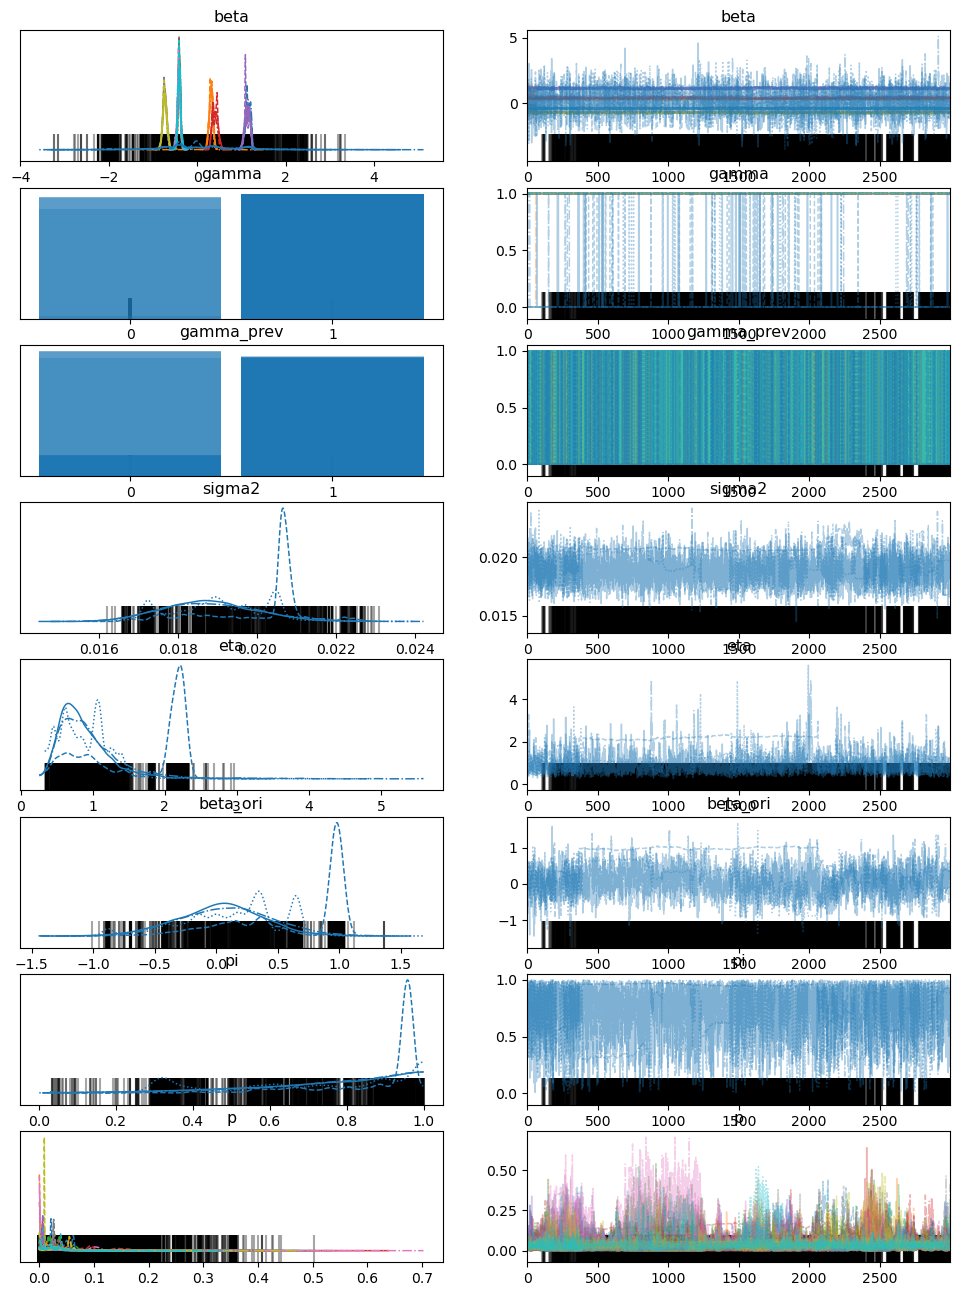

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]  1.147  0.059   1.035    1.243      0.005    0.003     154.0   
beta[1]  0.311  0.068   0.231    0.390      0.002    0.003     192.0   
beta[2] -0.412  0.028  -0.465   -0.358      0.002    0.001     204.0   
beta[3]  0.402  0.062   0.297    0.518      0.005    0.003     169.0   
beta[4]  1.130  0.057   1.034    1.233      0.004    0.003     170.0   
...        ...    ...     ...      ...        ...      ...       ...   
p[25]    0.031  0.023   0.000    0.060      0.001    0.001     103.0   
p[26]    0.063  0.079   0.000    0.184      0.024    0.017      11.0   
p[27]    0.033  0.029   0.000    0.079      0.006    0.004      23.0   
p[28]    0.039  0.037   0.000    0.081      0.007    0.005      16.0   
p[29]    0.029  0.026   0.000    0.065      0.004    0.003      36.0   

         ess_tail  r_hat  
beta[0]     596.0   1.02  
beta[1]    1217.0   1.01  
beta[2]    1052.0   1.03  
beta[3]     754.0   1.02  


In [457]:

# Step 1: Generate simulated data
np.random.seed(42)
N = 3000  # Number of samples
D = 11  # Number of predictors


# Step 2: Define the PyMC model
with pm.Model() as model:
    # Priors
    # Beta for regression coefficients, grouped into classes
    alpha = pm.HalfNormal("alpha", sigma=8.0)  # Dirichlet prior concentration parameter
    #alpha=1
    p = pm.Dirichlet("p", a=pm.math.ones(30) * alpha, shape=30)  # Class probabilities
 #10 0 1 2 3 4 
    S = pm.Categorical("S", p=p, shape=D)# bp=nel shape  1 1 1  # Class assignment for predictors (0-9)
    #[1 3 5 7 9]
    eta = pm.InverseGamma("eta", alpha=4, beta=4)  # Variance for beta_m
    mu_0=pm.Normal("beta_ori",mu=0,sigma=1)
    beta_m = pm.Normal("beta_m", mu=mu_0, sigma=pm.math.sqrt(eta), shape=30)  # Regression coefficients for each class
    
    # Ensure S only indexes valid categories of beta_m
    beta = pm.Deterministic("beta", beta_m[S])  # Map beta based on S
    
    # Sparsity indicator gamma
    pi = pm.Beta("pi", alpha=1, beta=1)  # Probability of gamma=1
    gamma_prev = pm.Bernoulli("gamma_prev", p=0.5, shape=D)  # 初始值
    rho = 0.8  # 控制gamma的平稳性（越接近1越稳定）
    gamma = pm.Bernoulli("gamma", p=rho * gamma_prev + (1 - rho) * pi, shape=D)

    #gamma = pm.Bernoulli("gamma", p=pi, shape=D)

    # Noise variance (sigma^2)
    sigma2 = pm.InverseGamma("sigma2", alpha=4, beta=4)  # Prior for noise variance

    # Observed data likelihood
    mu = pm.math.dot(X_with_intercept, beta * gamma)  # Predicted mean
    y_obs = pm.Normal("y_obs", mu=mu, sigma=pm.math.sqrt(sigma2), observed=y)

    # Inference
    
    trace = pm.sample(N, tune=500, chains=4,step=pm.NUTS(target_accept=0.95), return_inferencedata=True)


# Step 3: Analyze and visualize the results
az.plot_trace(trace, var_names=["beta", "gamma", "gamma_prev","sigma2", "eta", "beta_ori","pi", "p"])
plt.show()
summary=az.summary(trace, var_names=["beta", "gamma","gamma_prev", "sigma2", "eta","beta_ori", "pi", "p"])
print(summary)

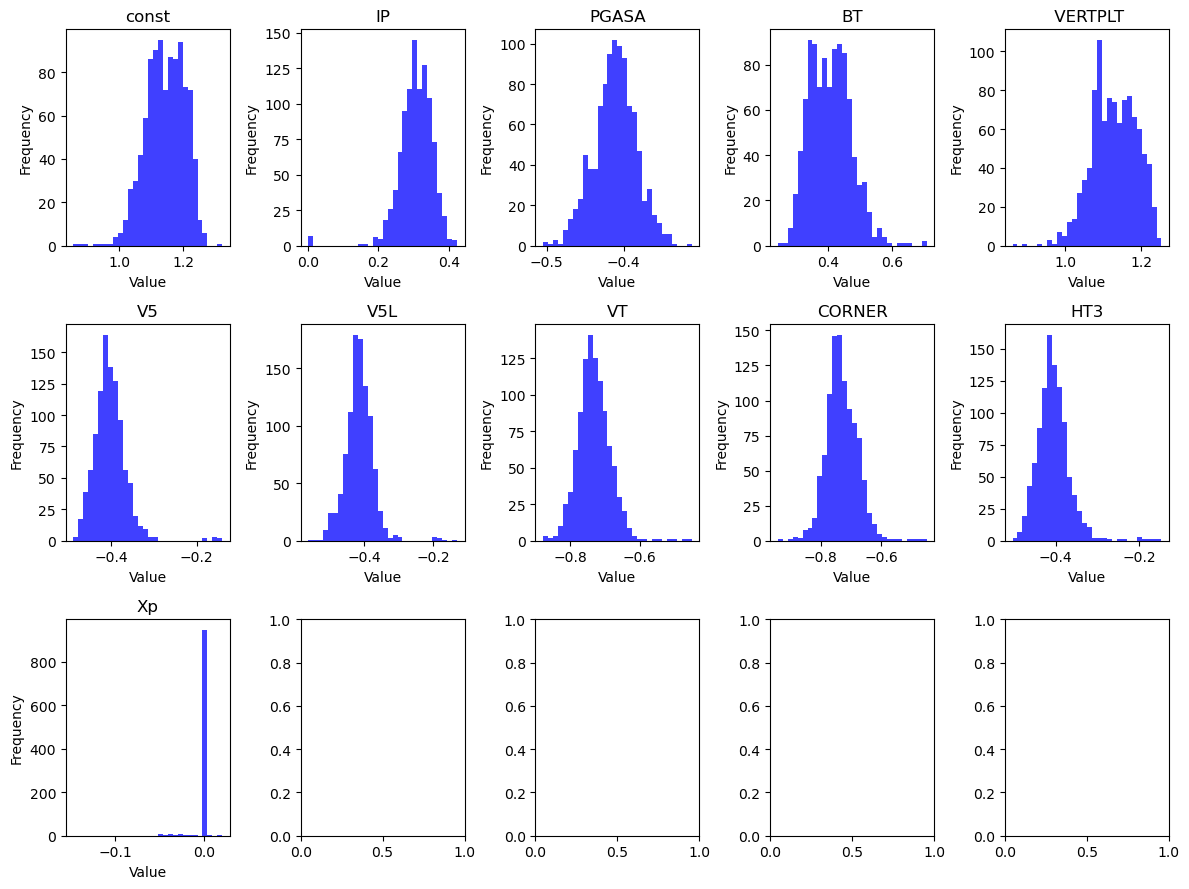

[1.    0.993 1.    1.    1.    1.    1.    1.    1.    1.    0.052]
[ 1.14239122  0.30649008 -0.41091889  0.40588148  1.1278333  -0.40268514
 -0.41502333 -0.73118394 -0.72985621 -0.40464498 -0.00160155]
[13.587 14.144 15.701 14.249 14.696 15.828 16.007 17.386 17.42  15.848
 14.709]
1000 samples' R² values=: 0.9909


In [487]:
# 从后验中随机抽取 10 个样本
num_samples = 1000
posterior_indices = np.random.choice(
    trace.posterior["beta"].stack(samples=["chain", "draw"]).shape[1], 
    size=num_samples, 
    replace=False
)

# 定义新数据
 # 新数据 (10 个样本)

# 存储预测结果
beta_new_look = []
predictions = []
S_new = []
gamma_new=[]
for idx in posterior_indices:
    beta_sample = trace.posterior["beta"].stack(samples=["chain", "draw"]).values[:, idx]
    gamma_sample = trace.posterior["gamma"].stack(samples=["chain", "draw"]).values[:, idx]
    S_sample = trace.posterior["S"].stack(samples=["chain", "draw"]).values[:, idx]
    sigma_sample = np.sqrt(trace.posterior["sigma2"].stack(samples=["chain", "draw"]).values[idx])
    #gamma_binary = (gamma_post_mean > 0.5).astype(int)
    # 计算预测值
    mu_pred = X_with_intercept @ (beta_sample * gamma_sample)  # 预测均值
    y_pred = np.random.normal(mu_pred, sigma_sample, size=X_with_intercept.shape[0])  # 从预测分布采样
    S_new.append(gamma_sample*beta_sample)
    beta_new_look.append(S_sample)
    gamma_new.append(gamma_sample)
    predictions.append(y_pred)
S_new1 = np.array(S_new)
gamma_new = np.array(gamma_new)
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(12, 9))
axes = axes.flatten()

for i in range(11):
    ax = axes[i]
    # 只考虑 gamma 为 1 的情况
    #filtered_beta = S_new1[:, i][gamma_new[:, i] == 1]
    filtered_beta = S_new1[:, i]
    ax.hist(filtered_beta, bins=30, alpha=0.75, color='blue')
    ax.set_title(f'{X_with_intercept.columns[i]}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distribution.png', format='png', dpi=300, transparent=True)
plt.show()
S_mean_new = np.array(S_new).mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)
print(gamma_mean)

predictions = np.array(predictions).T  
pred_mean = predictions.mean(axis=1) 
print(S_mean_new)
print(beta_new_look_new)
SS_res = np.sum((pred_mean - y) ** 2)
SS_tot = np.sum((y - np.mean(y)) ** 2)
R_squared = 1 - (SS_res / SS_tot)
print(f"1000 samples' R² values=: {R_squared:.4f}")

In [460]:

trace.to_netcdf("final_nemin_trace.nc")

# 查看并保存summary
summary_df = az.summary(trace, var_names=["beta", "gamma","gamma_prev", "sigma2", "beta_ori","eta", "pi", "p"])
print(summary_df)
summary_df.to_csv("final_nemin_trace.csv")

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]  1.147  0.059   1.035    1.243      0.005    0.003     154.0   
beta[1]  0.311  0.068   0.231    0.390      0.002    0.003     192.0   
beta[2] -0.412  0.028  -0.465   -0.358      0.002    0.001     204.0   
beta[3]  0.402  0.062   0.297    0.518      0.005    0.003     169.0   
beta[4]  1.130  0.057   1.034    1.233      0.004    0.003     170.0   
...        ...    ...     ...      ...        ...      ...       ...   
p[25]    0.031  0.023   0.000    0.060      0.001    0.001     103.0   
p[26]    0.063  0.079   0.000    0.184      0.024    0.017      11.0   
p[27]    0.033  0.029   0.000    0.079      0.006    0.004      23.0   
p[28]    0.039  0.037   0.000    0.081      0.007    0.005      16.0   
p[29]    0.029  0.026   0.000    0.065      0.004    0.003      36.0   

         ess_tail  r_hat  
beta[0]     596.0   1.02  
beta[1]    1217.0   1.01  
beta[2]    1052.0   1.03  
beta[3]     754.0   1.02  


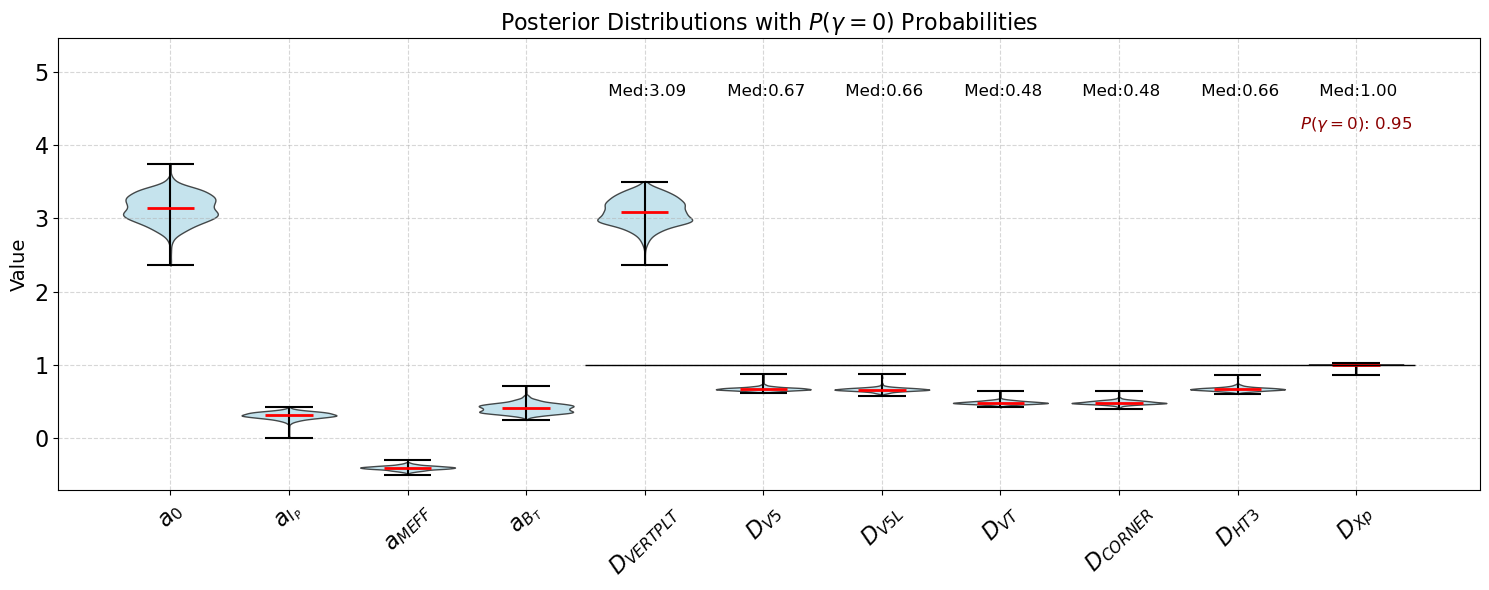


Gamma means: [1.    0.993 1.    1.    1.    1.    1.    1.    1.    1.    0.052]
S means: [ 1.14239122  0.30649008 -0.41091889  0.40588148  1.1278333  -0.40268514
 -0.41502333 -0.73118394 -0.72985621 -0.40464498 -0.00160155]
Beta new look means: [13.587 14.144 15.701 14.249 14.696 15.828 16.007 17.386 17.42  15.848
 14.709]

Predictions shape: (486,)
1000 samples' RMSE: 0.0484


In [512]:
import numpy as np
import matplotlib.pyplot as plt

# 修改后的变量名称列表 - 将"D for XXX"改为"$D_{XXX}$"格式
titles = ["$a_0$", "$a_{I_P}$", "$a_{MEFF}$", "$a_{B_T}$", 
          "$D_{VERTPLT}$", "$D_{V5}$", "$D_{V5L}$", "$D_{VT}$","$D_{CORNER}$","$D_{HT3}$",'$D_{Xp}$']

S_new1 = np.array(S_new)  # 转换为 NumPy 数组
gamma_new = np.array(gamma_new)  # 确保 gamma_new 是 NumPy 数组
D = 11  # 现在有6个变量

# 计算每个变量 gamma 为 0 的概率
gamma_prob_0 = np.mean(gamma_new < 0.5, axis=0)  # 概率 = (gamma < 0.5) 的均值

# 准备数据
data = []
for i in range(D):
    if i == 0 or i in [4, 5,6,7,8,9,10]:  # 需要exp变换的变量
        filtered_beta = np.exp(S_new1[:, i])
    else:
        filtered_beta = S_new1[:, i]
    data.append(filtered_beta)

# 创建图形
plt.figure(figsize=(15,6))  # 保持与原来相同的图形大小

# 创建小提琴图
violin_parts = plt.violinplot(data, 
                             showmeans=False, 
                             showmedians=True,
                             showextrema=True,
                             widths=0.8)

# 设置小提琴图的颜色和样式
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

# 设置统计线的样式
violin_parts['cmedians'].set_color('red')
violin_parts['cmedians'].set_linewidth(2)
violin_parts['cmaxes'].set_color('black')
violin_parts['cmins'].set_color('black')
violin_parts['cbars'].set_color('black')

# 设置x轴标签
xticks_pos = range(1, D+1)
plt.xticks(xticks_pos, titles, rotation=45, ha='center', fontsize=14)
# 从D_VERTPLT开始画水平实线
start_idx = 4  # D_VERTPLT是第5个变量（索引4）
x_start = start_idx + 1  # 小提琴图位置从1开始
ax = plt.gca()
ax.hlines(y=1.0, xmin=x_start-0.5, xmax=len(data)+0.5,
          colors='black', linestyles='-', linewidth=1)
# 在每个小提琴上方添加gamma=0的概率标注（仅当概率>0时显示）
for pos, i in zip(xticks_pos, range(D)):
    if gamma_prob_0[i] > 0.05:  # 只显示非零概率
        prob_text = f"$P(γ=0)$: {gamma_prob_0[i]:.2f}"
        plt.text(pos, plt.ylim()[1]*1.05, prob_text, 
                 ha='center', va='bottom', fontsize=12, color='darkred')
# 在每个小提琴上方添加中位数标注（Med: xxx）
y_max=np.max(S_new1)
# 计算中位数
medians = [np.median(d) for d in data]

# 获取当前 ylim，用于设定统一的高度
ylim = plt.ylim()
y_top = ylim[1]

# 仅显示后面五个变量的中位数（索引1到5，对应位置2到6）
for pos, median in zip(xticks_pos[4:], medians[4:]):
    plt.text(pos, y_top * 1.17, f" Med:{median:.2f}", 
             ha='center', va='bottom', fontsize=12, color='black')

# 调整 ylim 为显示足够空间
plt.ylim(ylim[0], y_top * 1.20)
# 添加网格和标签
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylabel('Value', fontsize=14)
plt.title('Posterior Distributions with $P(γ=0)$ Probabilities', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=16)

# 调整y轴范围，为标注留出空间
ylim = plt.ylim()
plt.ylim(ylim[0], ylim[1]*1.15)  # 增加15%的上部空间

# 调整布局
plt.tight_layout()
plt.savefig('violin_plot_nemin.png', format='png', dpi=300, transparent=True)
plt.show()

# 其余统计计算保持不变
S_mean_new = S_new1.mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)  
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)

print("\nGamma means:", gamma_mean)
print("S means:", S_mean_new)
print("Beta new look means:", beta_new_look_new)

pred_mean = predictions.mean(axis=1)
print("\nPredictions shape:", pred_mean.shape)
rmse = np.sqrt(mean_squared_error(y, pred_mean))
print(f"1000 samples' RMSE: {rmse:.4f}")

In [38]:

import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

# 指定你想在新 DataFrame 中包含的列
columns_to_include = ['TOK','Nemin', 'SPLASMA','BT','IP','a','AMIN','RGEO','PLTH','NEL','PGASA',"DIVCON",'Q95','KAPPA']
new_df = df[columns_to_include].copy()
mu0 = 4 * np.pi * 1e-7

new_df['BP']=1000000*(mu0 * new_df['IP']) / (new_df['SPLASMA']/(2 * np.pi * new_df['RGEO']))





columns_to_include_for_regre = ['Nemin','BP','SPLASMA','PGASA','IP','BT','AMIN','a','Q95','KAPPA']
unique_divcon = new_df['DIVCON'].unique()

# 2. 向原始 DataFrame 添加新列
for divcon_type in unique_divcon:
    new_df[divcon_type] = (new_df['DIVCON'] == divcon_type).astype(int)
multi_df = new_df[columns_to_include_for_regre].copy()
multi_df = multi_df.apply(np.log)
x = multi_df[['IP','PGASA','BT']] 
x[unique_divcon] = new_df[unique_divcon]
#x['Xp'] = x[['Xptref','Xpthigh','Xptin']].max(axis=1)
x.drop(['STANDARD'], axis=1, inplace=True)
x.drop(['Xptref','Xpthigh','Xptin'], axis=1, inplace=True)
#x['V5'] = x[['V5E','V5C','V5']].max(axis=1)

x['VH'] = x[['V5','V5L','V5E','V5C','HT3R','HT3L','HT3']].max(axis=1)
x.drop(['V5','V5L','V5E','V5C','HT3R','HT3L','HT3'], axis=1, inplace=True)

x['CV'] = x[['CORNER','VT']].max(axis=1)
x.drop(['CORNER','VT'], axis=1, inplace=True)
#x.drop(['HT3R','HT3L'], axis=1, inplace=True)
X_with_intercept = sm.add_constant(x)
y=multi_df["Nemin"]
model = sm.OLS(y, X_with_intercept)
results = model.fit()

# 打印详细统计结果
print(results.summary())

# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")
    # 打印 RMSE
y_pred = results.predict(X_with_intercept)  # 预测值
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"RMSE: {rmse:.3f}")
# 获取 90% 置信区间
conf_int_90 = results.conf_int(alpha=0.1)


print("\n90% 置信区间：\n", conf_int_90)
new_df[columns_to_include_for_regre]

                            OLS Regression Results                            
Dep. Variable:                  Nemin   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     8872.
Date:                Sun, 11 May 2025   Prob (F-statistic):               0.00
Time:                        01:59:23   Log-Likelihood:                 787.17
No. Observations:                 486   AIC:                            -1560.
Df Residuals:                     479   BIC:                            -1531.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1591      0.022     53.831      0.0

/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_1404/627104547.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[unique_divcon] = new_df[unique_divcon]
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_1404/627104547.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[unique_divcon] = new_df[unique_divcon]
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_1404/627104547.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

,Nemin,BP,SPLASMA,PGASA,IP,BT,AMIN,a,Q95,KAPPA
0,14.0,0.666565,7.42158,2.000,0.931812,5.33923,0.216421,3.106857,4.26029,1.69737
1,14.0,0.470971,7.36968,2.000,0.655357,5.35375,0.217660,3.081747,5.89660,1.67073
2,14.0,0.456655,7.37796,2.000,0.634247,5.32586,0.217388,3.094858,6.19549,1.67962
3,14.0,0.734135,7.43647,2.000,1.030660,5.33346,0.217080,3.090423,3.86097,1.69789
4,14.0,0.544822,6.70529,2.000,0.681653,5.26510,0.213690,3.176396,4.40365,1.44202
...,...,...,...,...,...,...,...,...,...,...
663,3.2,0.410025,137.46400,1.972,2.470630,2.97606,0.928461,3.111989,3.71799,1.68223
664,3.2,0.451442,137.34500,1.979,2.715140,2.97667,0.924404,3.128751,3.36799,1.68578
665,3.2,0.451495,137.39200,1.972,2.716620,2.97529,0.925206,3.125769,3.37939,1.68724
666,3.2,0.451793,137.47400,1.991,2.721300,2.97753,0.926219,3.120903,3.37763,1.68593


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [alpha, p, eta, beta_ori, beta_m, pi, sigma2]
>CategoricalGibbsMetropolis: [S]
>BinaryGibbsMetropolis: [gamma_prev, gamma]


Output()

Sampling 4 chains for 500 tune and 3_000 draw iterations (2_000 + 12_000 draws total) took 531 seconds.
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 3050 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is

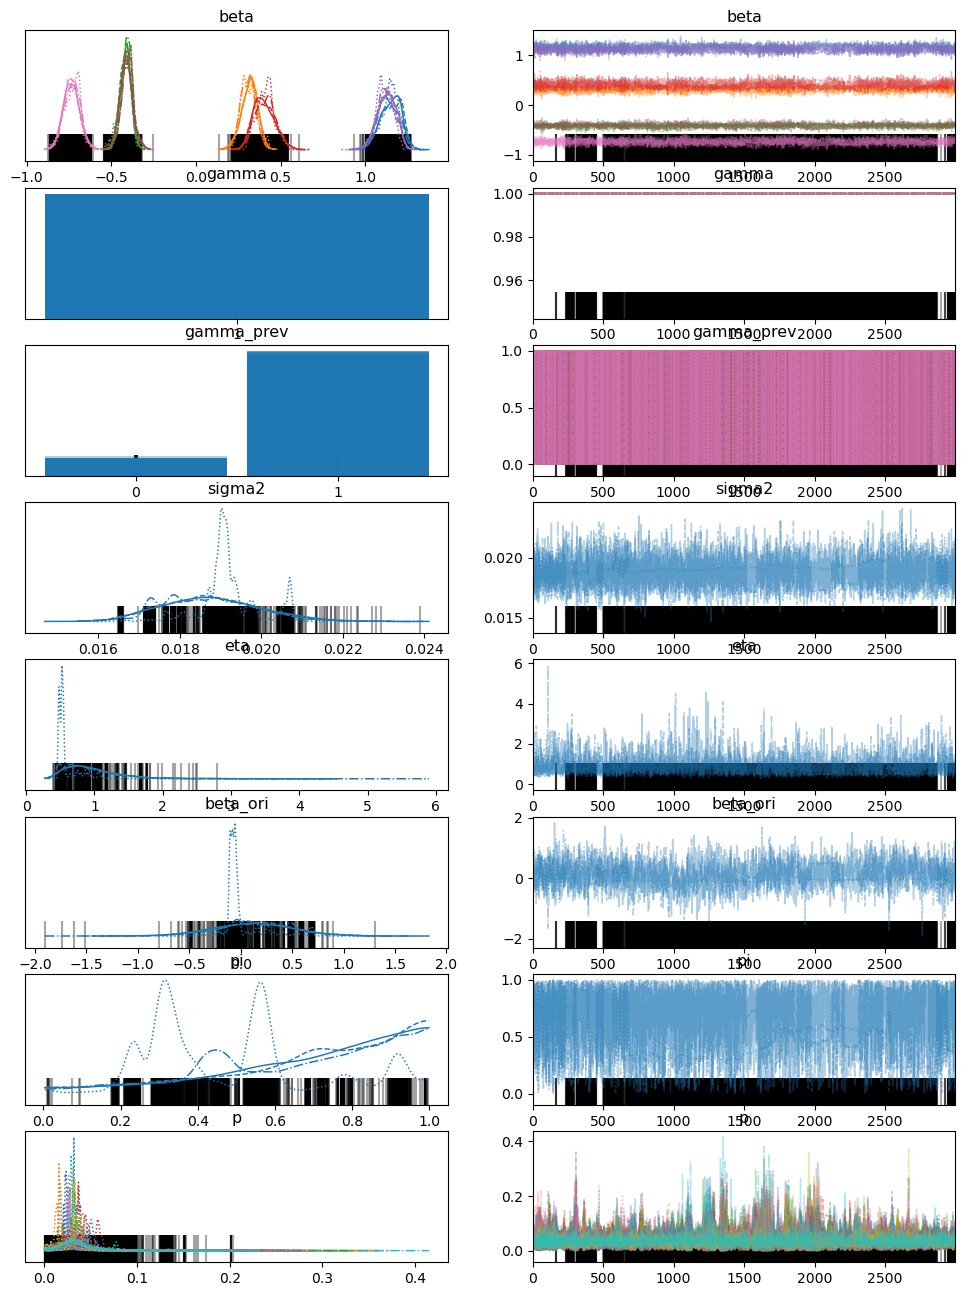

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]        1.147  0.059   1.038    1.255      0.005    0.003     159.0   
beta[1]        0.313  0.047   0.226    0.400      0.003    0.002     308.0   
beta[2]       -0.416  0.034  -0.483   -0.357      0.002    0.002     240.0   
beta[3]        0.406  0.060   0.296    0.516      0.004    0.003     215.0   
beta[4]        1.122  0.053   1.019    1.213      0.004    0.003     180.0   
beta[5]       -0.410  0.037  -0.485   -0.341      0.002    0.002     319.0   
beta[6]       -0.735  0.047  -0.822   -0.647      0.002    0.002     425.0   
gamma[0]       1.000  0.000   1.000    1.000      0.000    0.000   12000.0   
gamma[1]       1.000  0.000   1.000    1.000      0.000    0.000   12000.0   
gamma[2]       1.000  0.000   1.000    1.000      0.000    0.000   12000.0   
gamma[3]       1.000  0.000   1.000    1.000      0.000    0.000   12000.0   
gamma[4]       1.000  0.000   1.000    1.000      0.000    0.000

In [519]:

# Step 1: Generate simulated data
np.random.seed(42)
N = 3000  # Number of samples
D = 7  # Number of predictors


# Step 2: Define the PyMC model
with pm.Model() as model:
    # Priors
    # Beta for regression coefficients, grouped into classes
    alpha = pm.HalfNormal("alpha", sigma=8.0)  # Dirichlet prior concentration parameter
    #alpha=1
    p = pm.Dirichlet("p", a=pm.math.ones(30) * alpha, shape=30)  # Class probabilities
 #10 0 1 2 3 4 
    S = pm.Categorical("S", p=p, shape=D)# bp=nel shape  1 1 1  # Class assignment for predictors (0-9)
    #[1 3 5 7 9]
    eta = pm.InverseGamma("eta", alpha=4, beta=4)  # Variance for beta_m
    mu_0=pm.Normal("beta_ori",mu=0,sigma=1)
    beta_m = pm.Normal("beta_m", mu=mu_0, sigma=pm.math.sqrt(eta), shape=30)  # Regression coefficients for each class
    
    # Ensure S only indexes valid categories of beta_m
    beta = pm.Deterministic("beta", beta_m[S])  # Map beta based on S
    
    # Sparsity indicator gamma
    pi = pm.Beta("pi", alpha=1, beta=1)  # Probability of gamma=1
    gamma_prev = pm.Bernoulli("gamma_prev", p=0.5, shape=D)  # 初始值
    rho = 0.8  # 控制gamma的平稳性（越接近1越稳定）
    gamma = pm.Bernoulli("gamma", p=rho * gamma_prev + (1 - rho) * pi, shape=D)

    #gamma = pm.Bernoulli("gamma", p=pi, shape=D)

    # Noise variance (sigma^2)
    sigma2 = pm.InverseGamma("sigma2", alpha=4, beta=4)  # Prior for noise variance

    # Observed data likelihood
    mu = pm.math.dot(X_with_intercept, beta * gamma)  # Predicted mean
    y_obs = pm.Normal("y_obs", mu=mu, sigma=pm.math.sqrt(sigma2), observed=y)

    # Inference
    
    trace = pm.sample(N, tune=500, chains=4,step=pm.NUTS(target_accept=0.95), return_inferencedata=True)


# Step 3: Analyze and visualize the results
az.plot_trace(trace, var_names=["beta", "gamma", "gamma_prev","sigma2", "eta", "beta_ori","pi", "p"])
plt.show()
summary=az.summary(trace, var_names=["beta", "gamma","gamma_prev", "sigma2", "eta","beta_ori", "pi", "p"])
print(summary)

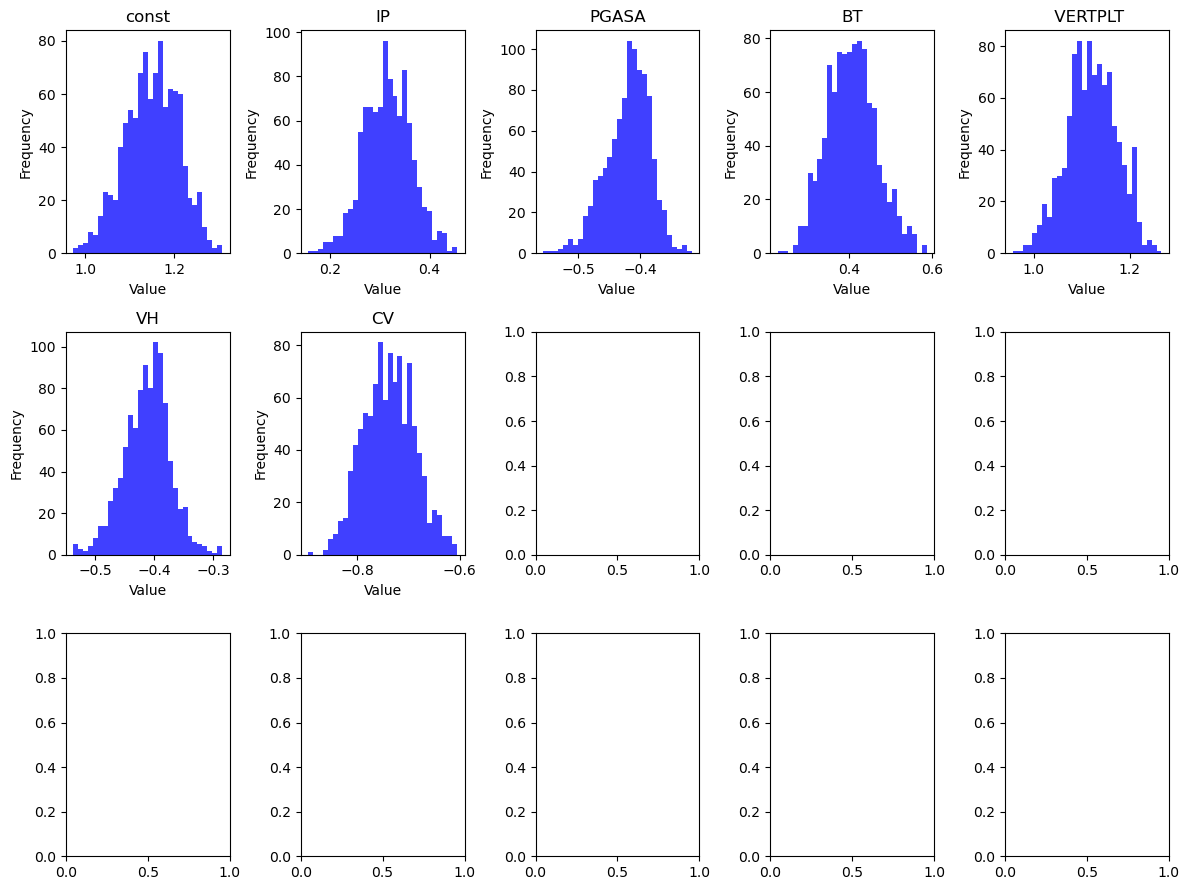

[1. 1. 1. 1. 1. 1. 1.]
[ 1.14983884  0.31518808 -0.420012    0.40705179  1.12102496 -0.41256702
 -0.73799959]
[13.514 13.453 14.358 15.051 15.321 14.183 15.178]
1000 samples' R² values=: 0.9910


In [41]:
# 从后验中随机抽取 10 个样本
num_samples = 1000
posterior_indices = np.random.choice(
    trace.posterior["beta"].stack(samples=["chain", "draw"]).shape[1], 
    size=num_samples, 
    replace=False
)

# 定义新数据
 # 新数据 (10 个样本)

# 存储预测结果
beta_new_look = []
predictions = []
S_new = []
gamma_new=[]
for idx in posterior_indices:
    beta_sample = trace.posterior["beta"].stack(samples=["chain", "draw"]).values[:, idx]
    gamma_sample = trace.posterior["gamma"].stack(samples=["chain", "draw"]).values[:, idx]
    S_sample = trace.posterior["S"].stack(samples=["chain", "draw"]).values[:, idx]
    sigma_sample = np.sqrt(trace.posterior["sigma2"].stack(samples=["chain", "draw"]).values[idx])
    #gamma_binary = (gamma_post_mean > 0.5).astype(int)
    # 计算预测值
    mu_pred = X_with_intercept @ (beta_sample * gamma_sample)  # 预测均值
    y_pred = np.random.normal(mu_pred, sigma_sample, size=X_with_intercept.shape[0])  # 从预测分布采样
    S_new.append(gamma_sample*beta_sample)
    beta_new_look.append(S_sample)
    gamma_new.append(gamma_sample)
    predictions.append(y_pred)
S_new1 = np.array(S_new)
gamma_new = np.array(gamma_new)
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(12, 9))
axes = axes.flatten()

for i in range(7):
    ax = axes[i]
    # 只考虑 gamma 为 1 的情况
    #filtered_beta = S_new1[:, i][gamma_new[:, i] == 1]
    filtered_beta = S_new1[:, i]
    ax.hist(filtered_beta, bins=30, alpha=0.75, color='blue')
    ax.set_title(f'{X_with_intercept.columns[i]}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distribution.png', format='png', dpi=300, transparent=True)
plt.show()
S_mean_new = np.array(S_new).mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)
print(gamma_mean)

predictions = np.array(predictions).T  
pred_mean = predictions.mean(axis=1) 
print(S_mean_new)
print(beta_new_look_new)
SS_res = np.sum((pred_mean - y) ** 2)
SS_tot = np.sum((y - np.mean(y)) ** 2)
R_squared = 1 - (SS_res / SS_tot)
print(f"1000 samples' R² values=: {R_squared:.4f}")

In [522]:

trace.to_netcdf("new_final_nemin_trace.nc")

# 查看并保存summary
summary_df = az.summary(trace, var_names=["beta", "gamma","gamma_prev", "sigma2", "beta_ori","eta", "pi", "p"])
print(summary_df)
summary_df.to_csv("new_final_nemin_trace.csv")

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]        1.147  0.059   1.038    1.255      0.005    0.003     159.0   
beta[1]        0.313  0.047   0.226    0.400      0.003    0.002     308.0   
beta[2]       -0.416  0.034  -0.483   -0.357      0.002    0.002     240.0   
beta[3]        0.406  0.060   0.296    0.516      0.004    0.003     215.0   
beta[4]        1.122  0.053   1.019    1.213      0.004    0.003     180.0   
beta[5]       -0.410  0.037  -0.485   -0.341      0.002    0.002     319.0   
beta[6]       -0.735  0.047  -0.822   -0.647      0.002    0.002     425.0   
gamma[0]       1.000  0.000   1.000    1.000      0.000    0.000   12000.0   
gamma[1]       1.000  0.000   1.000    1.000      0.000    0.000   12000.0   
gamma[2]       1.000  0.000   1.000    1.000      0.000    0.000   12000.0   
gamma[3]       1.000  0.000   1.000    1.000      0.000    0.000   12000.0   
gamma[4]       1.000  0.000   1.000    1.000      0.000    0.000

In [40]:


# 读取 MCMC 采样数据
trace = az.from_netcdf("new_final_nemin_trace.nc")

# 查看 trace 中的变量
print(trace.posterior)


<xarray.Dataset> Size: 9MB
Dimensions:           (chain: 4, draw: 3000, S_dim_0: 7, beta_m_dim_0: 30,
                       gamma_prev_dim_0: 7, gamma_dim_0: 7, p_dim_0: 30,
                       beta_dim_0: 7)
Coordinates:
  * chain             (chain) int64 32B 0 1 2 3
  * draw              (draw) int64 24kB 0 1 2 3 4 5 ... 2995 2996 2997 2998 2999
  * S_dim_0           (S_dim_0) int64 56B 0 1 2 3 4 5 6
  * beta_m_dim_0      (beta_m_dim_0) int64 240B 0 1 2 3 4 5 ... 25 26 27 28 29
  * gamma_prev_dim_0  (gamma_prev_dim_0) int64 56B 0 1 2 3 4 5 6
  * gamma_dim_0       (gamma_dim_0) int64 56B 0 1 2 3 4 5 6
  * p_dim_0           (p_dim_0) int64 240B 0 1 2 3 4 5 6 ... 24 25 26 27 28 29
  * beta_dim_0        (beta_dim_0) int64 56B 0 1 2 3 4 5 6
Data variables:
    S                 (chain, draw, S_dim_0) int64 672kB ...
    beta_ori          (chain, draw) float64 96kB ...
    beta_m            (chain, draw, beta_m_dim_0) float64 3MB ...
    gamma_prev        (chain, draw, gamma_prev_dim_

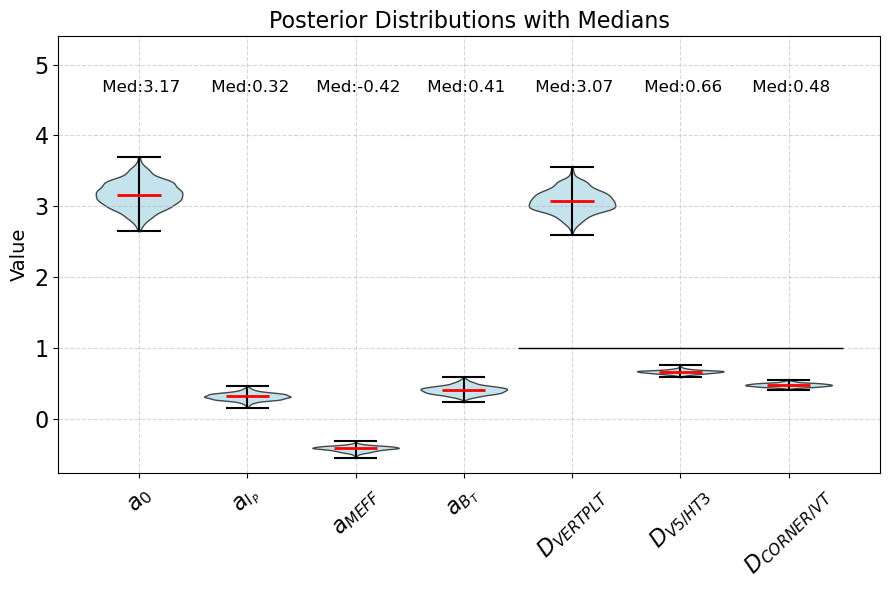


Gamma means: [1. 1. 1. 1. 1. 1. 1.]
S means: [ 1.14983884  0.31518808 -0.420012    0.40705179  1.12102496 -0.41256702
 -0.73799959]
Beta new look means: [13.514 13.453 14.358 15.051 15.321 14.183 15.178]

Predictions shape: (486,)
1000 samples' RMSE: 0.0480


In [43]:
import numpy as np
import matplotlib.pyplot as plt

# 修改后的变量名称列表 - 将"D for XXX"改为"$D_{XXX}$"格式
titles = ["$a_0$", "$a_{I_P}$", "$a_{MEFF}$", "$a_{B_T}$", 
          "$D_{VERTPLT}$", "$D_{V5/HT3}$", "$D_{CORNER/VT}$"]

S_new1 = np.array(S_new)  # 转换为 NumPy 数组
gamma_new = np.array(gamma_new)  # 确保 gamma_new 是 NumPy 数组
D = 7  # 现在有6个变量

# 计算每个变量 gamma 为 0 的概率
gamma_prob_0 = np.mean(gamma_new < 0.5, axis=0)  # 概率 = (gamma < 0.5) 的均值

# 准备数据
data = []
for i in range(D):
    if i == 0 or i in [4, 5,6]:  # 需要exp变换的变量
        filtered_beta = np.exp(S_new1[:, i])
    else:
        filtered_beta = S_new1[:, i]
    data.append(filtered_beta)

# 创建图形
plt.figure(figsize=(9,6))  # 保持与原来相同的图形大小

# 创建小提琴图
violin_parts = plt.violinplot(data, 
                             showmeans=False, 
                             showmedians=True,
                             showextrema=True,
                             widths=0.8)

# 设置小提琴图的颜色和样式
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

# 设置统计线的样式
violin_parts['cmedians'].set_color('red')
violin_parts['cmedians'].set_linewidth(2)
violin_parts['cmaxes'].set_color('black')
violin_parts['cmins'].set_color('black')
violin_parts['cbars'].set_color('black')

# 设置x轴标签
xticks_pos = range(1, D+1)
plt.xticks(xticks_pos, titles, rotation=45, ha='center', fontsize=14)
# 从D_VERTPLT开始画水平实线
start_idx = 4  # D_VERTPLT是第5个变量（索引4）
x_start = start_idx + 1  # 小提琴图位置从1开始
ax = plt.gca()
ax.hlines(y=1.0, xmin=x_start-0.5, xmax=len(data)+0.5,
          colors='black', linestyles='-', linewidth=1)
# 在每个小提琴上方添加gamma=0的概率标注（仅当概率>0时显示）
for pos, i in zip(xticks_pos, range(D)):
    if gamma_prob_0[i] > 0.05:  # 只显示非零概率
        prob_text = f"$P(γ=0)$: {gamma_prob_0[i]:.2f}"
        plt.text(pos, plt.ylim()[1]*1.05, prob_text, 
                 ha='center', va='bottom', fontsize=12, color='darkred')
# 在每个小提琴上方添加中位数标注（Med: xxx）
y_max=np.max(S_new1)
# 计算中位数
medians = [np.median(d) for d in data]

# 获取当前 ylim，用于设定统一的高度
ylim = plt.ylim()
y_top = ylim[1]

# 仅显示后面五个变量的中位数（索引1到5，对应位置2到6）
for pos, median in zip(xticks_pos[0:], medians[0:]):
    plt.text(pos, y_top * 1.17, f" Med:{median:.2f}", 
             ha='center', va='bottom', fontsize=12, color='black')

# 调整 ylim 为显示足够空间
plt.ylim(ylim[0], y_top * 1.20)
# 添加网格和标签
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylabel('Value', fontsize=14)
plt.title('Posterior Distributions with Medians', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=16)

# 调整y轴范围，为标注留出空间
ylim = plt.ylim()
plt.ylim(ylim[0], ylim[1]*1.15)  # 增加15%的上部空间

# 调整布局
plt.tight_layout()
#plt.savefig('new_violin_plot_nemin.png', format='png', dpi=300, transparent=True)
plt.show()

# 其余统计计算保持不变
S_mean_new = S_new1.mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)  
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)

print("\nGamma means:", gamma_mean)
print("S means:", S_mean_new)
print("Beta new look means:", beta_new_look_new)

pred_mean = predictions.mean(axis=1)
print("\nPredictions shape:", pred_mean.shape)
rmse = np.sqrt(mean_squared_error(y, pred_mean))
print(f"1000 samples' RMSE: {rmse:.4f}")

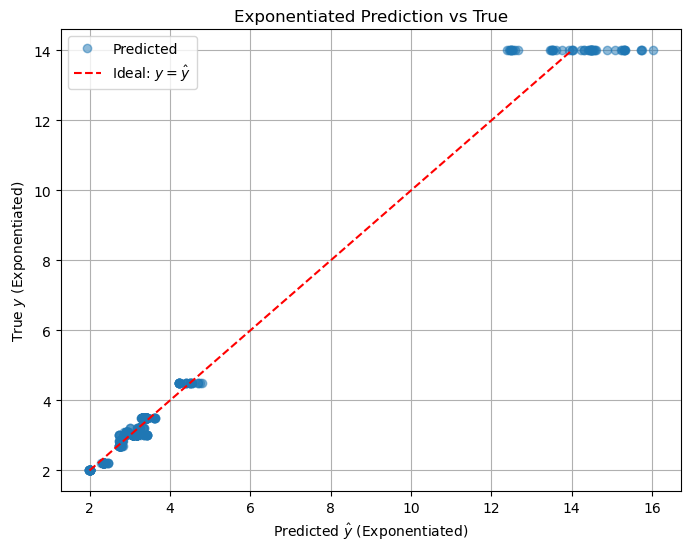

In [44]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import numpy as np

# 提取后500次样本（你可以按需调整）
posterior = trace.posterior
beta = posterior["beta"].values[:, -500:, :]     # shape: (chains, draws, D)
gamma = posterior["gamma"].values[:, -500:, :]   # shape: (chains, draws, D)
sigma2 = posterior["sigma2"].values[:, -500:]    # shape: (chains, draws)

# 合并 chain 和 draw 维度
beta = beta.reshape(-1, beta.shape[-1])        # shape: (500 * chains, D)
gamma = gamma.reshape(-1, gamma.shape[-1])     # shape: (500 * chains, D)
sigma2 = sigma2.reshape(-1)                    # shape: (500 * chains,)

# 手动预测 y
# y_pred_samples will be shape (num_draws, N)
X_input = X_with_intercept  # shape (N, D)
y_pred_samples = np.dot(X_input, (beta * gamma).T)  # shape: (N, num_draws)

# 如果需要加入高斯噪声 (optional)
# rng = np.random.default_rng(42)
# noise = rng.normal(0, np.sqrt(sigma2), size=y_pred_samples.T.shape).T
# y_pred_samples += noise

y_pred_mean = y_pred_samples.mean(axis=1)
y_pred_mean_exp = np.exp(y_pred_mean)
y = np.exp(y)
# 真实值 vs 平均预测
plt.figure(figsize=(8, 6))
# 绘制图形，不显示置信区间
plt.plot(
    y_pred_mean_exp, 
    y, 
    'o', alpha=0.5, 
    label='Predicted'
)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Ideal: $y = \\hat{y}$')
plt.xlabel("Predicted $\\hat{y}$ (Exponentiated)")
plt.ylabel("True $y$ (Exponentiated)")
plt.legend()
plt.grid(True)
plt.title("Exponentiated Prediction vs True")
plt.show()



In [46]:
df['Bayes_nemin_pred']=y_pred_mean_exp

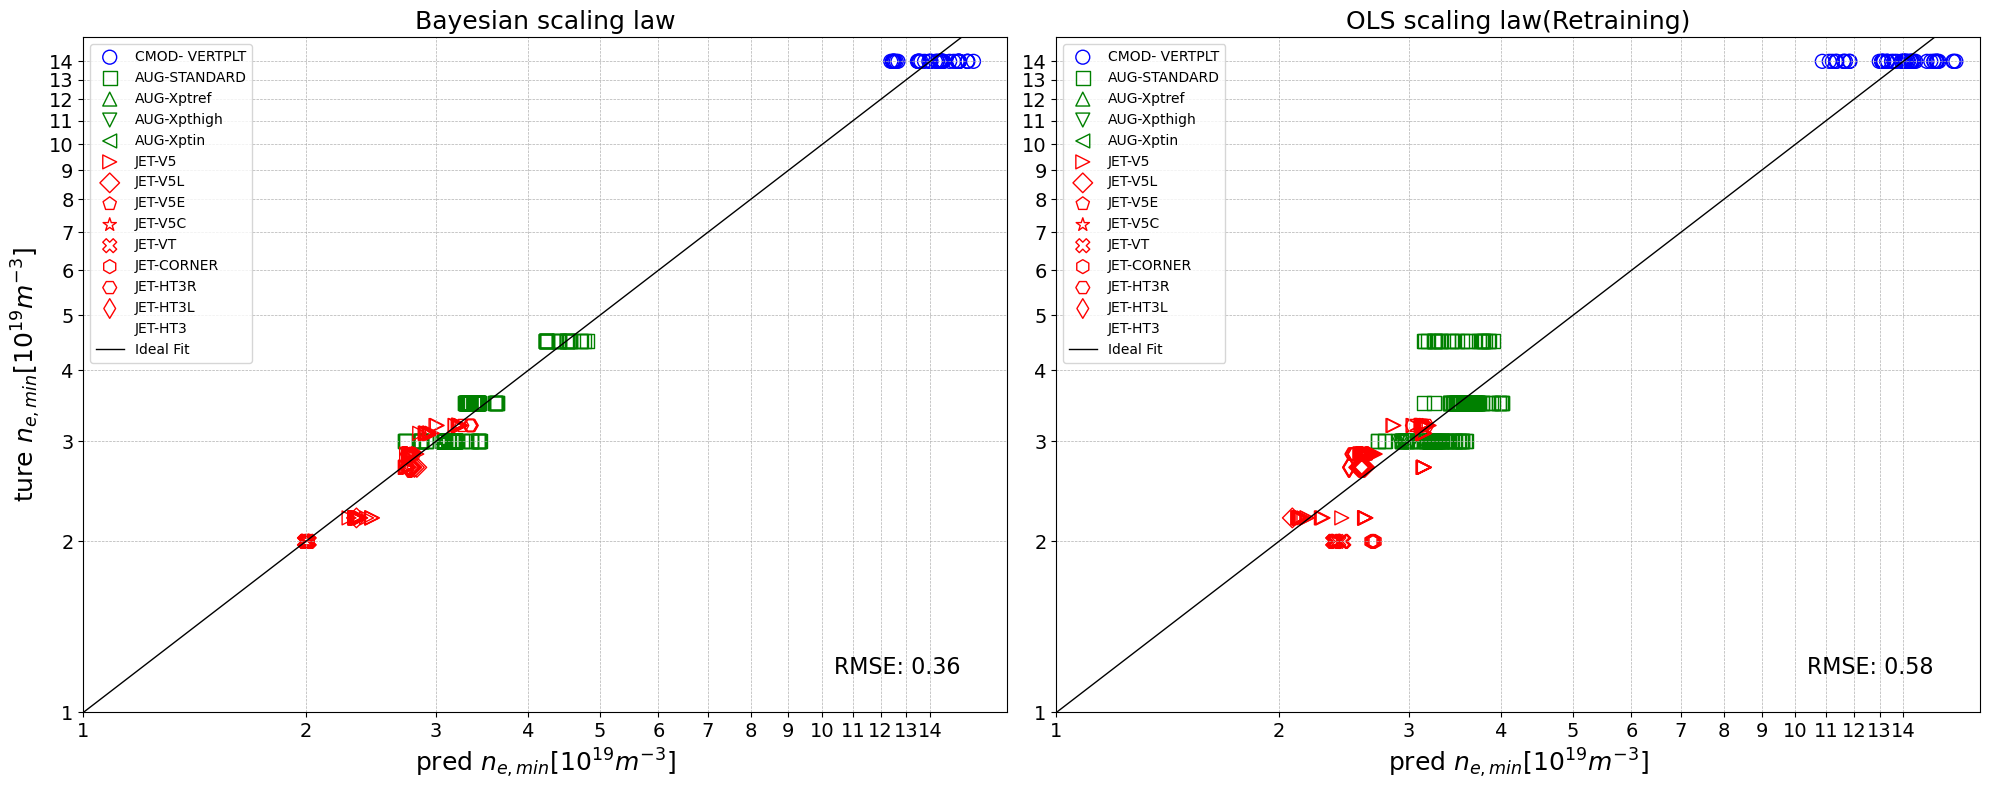

In [56]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter
import pandas as pd
import numpy as np
from itertools import cycle
from matplotlib import cm

# 假设 df 已经存在并包含以下列：IP, BT, AMIN, a, Nemin, TOK, DIVCON
# 定义公式和计算理想值
df['scaling_nemin_scal'] = 0.7 * (df['IP']**0.34) * (df['BT']**0.62) * (df['AMIN']**(-0.95)) * (df['a']**0.4)

# 自动获取唯一的 TOK 和 DIVCON 值
tok_values = df['TOK'].unique()
tok_unique = df['TOK'].unique()
divcon_values = df['DIVCON'].unique()
divcon_unique = df['DIVCON'].unique()
# 为 TOK 和 DIVCON 分配颜色和标记
color_map = {'CMOD': 'blue', 'AUG': 'green', 'JET': 'red'}
marker_styles = ['o', 's', '^', 'v', '<', '>', 'D', 'p', '*', 'X', 'h', 'H', 'd', '|']
marker_map = dict(zip(divcon_values, marker_styles[:len(divcon_values)]))


# 创建一行两列的图形
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# 第一张图
for tok in tok_unique:
    for divcon in divcon_unique:
        sub_df = df[(df['TOK'] == tok) & (df['DIVCON'] == divcon)]
        if sub_df.empty:
            continue  # 跳过没有数据的组合
        ax1.scatter(
            sub_df['Bayes_nemin_pred'],
            sub_df['Nemin'],
            facecolors='none',
            color=color_map[tok],
            marker=marker_map[divcon],
            label=f'{tok}-{divcon}',
            s=100
        )
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('pred $n_{e,min}[10^{19}m^{-3}]$', fontsize=18)
ax1.set_ylabel('ture $n_{e,min}[10^{19}m^{-3}]$', fontsize=18)
ax1.set_title('Bayesian scaling law', fontsize=18)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.xaxis.set_major_formatter(ScalarFormatter())
ax1.yaxis.set_major_formatter(ScalarFormatter())

# 设置 x 和 y 轴的范围
ax1.set_xlim(left=1)
ax1.set_ylim(bottom=1)
x_start, x_end = ax1.get_xlim()
y_start, y_end = ax1.get_ylim()
line_start = max(x_start, y_start)
line_end = min(x_end, y_end)
ax1.plot([line_start, line_end], [line_start, line_end],
         color='black', label='Ideal Fit', linewidth=1)

# 第二张图
for tok in tok_unique:
    for divcon in divcon_unique:
        sub_df = df[(df['TOK'] == tok) & (df['DIVCON'] == divcon)]
        if sub_df.empty:
            continue  # 跳过没有数据的组合
        ax2.scatter(
            sub_df['y_pred'],
            sub_df['Nemin'],
            facecolors='none',
            color=color_map[tok],
            marker=marker_map[divcon],
            label=f'{tok}-{divcon}',
            s=100
        )
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('pred $n_{e,min}[10^{19}m^{-3}]$', fontsize=18)
#ax2.set_ylabel('Nemin')
ax2.set_title('OLS scaling law(Retraining)', fontsize=18)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.xaxis.set_major_formatter(ScalarFormatter())
ax2.yaxis.set_major_formatter(ScalarFormatter())

# 设置 x 和 y 轴的范围
ax2.set_xlim(left=1)
ax2.set_ylim(bottom=1)

# 设置刻度
xmax1 = int(np.ceil(df['Nemin'].max()))
ymax1 = int(np.ceil(df['Nemin'].max()))
xticks1 = list(range(1, xmax1 + 1))
yticks1 = list(range(1, ymax1 + 1))

ax1.set_xticks(xticks1)
ax1.set_xticklabels([str(x) for x in xticks1], fontsize=14)
ax1.set_yticks(yticks1)
ax1.set_yticklabels([str(y) for y in yticks1], fontsize=14)
ax1.xaxis.set_major_formatter(FormatStrFormatter('%g'))
ax1.yaxis.set_major_formatter(FormatStrFormatter('%g'))
rmse1 = np.sqrt(((df['Bayes_nemin_pred'] - df['Nemin']) ** 2).mean())
ax1.text(0.95, 0.05, f'RMSE: {rmse1:.2}', transform=ax1.transAxes,
         ha='right', va='bottom', fontsize=16, color='black')

# -------- 图2坐标设置 --------
xmax2 = int(np.ceil(np.exp(y_pred).max()))
ymax2 = int(np.ceil(np.exp(y_pred).max()))
xticks2 = list(range(1, xmax2 + 1))
yticks2 = list(range(1, ymax2 + 1))

ax2.set_xticks(xticks2)
ax2.set_xticklabels([str(x) for x in xticks2])
ax2.set_yticks(yticks2)
ax2.set_yticklabels([str(y) for y in yticks2])
ax2.xaxis.set_major_formatter(FormatStrFormatter('%g'))
ax2.yaxis.set_major_formatter(FormatStrFormatter('%g'))

# 画对角线：y = x，从 max(x_start, y_start) 到 min(x_end, y_end)
x_start, x_end = ax2.get_xlim()
y_start, y_end = ax2.get_ylim()
line_start = max(x_start, y_start)
line_end = min(x_end, y_end)
ax2.plot([line_start, line_end], [line_start, line_end],
         color='black', label='Ideal Fit', linewidth=1)

# 设定相同的坐标轴范围和刻度
ax2.set_xlim(ax1.get_xlim())
ax2.set_ylim(ax1.get_ylim())
ax2.set_xticks(ax1.get_xticks())
ax2.set_yticks(ax1.get_yticks())
ax2.set_xticklabels([str(x) for x in ax1.get_xticks()], fontsize=14)
ax2.set_yticklabels([str(y) for y in ax1.get_yticks()], fontsize=14)
rmse2 = np.sqrt(((df['y_pred'] - df['Nemin']) ** 2).mean())
ax2.text(0.95, 0.05, f'RMSE: {rmse2:.2}', transform=ax2.transAxes,
         ha='right', va='bottom', fontsize=16, color='black')

# 显示图例
ax1.legend()
ax2.legend()

plt.tight_layout()
plt.savefig('nemin_new_result.png', format='png', dpi=600, transparent=True)
plt.show()



In [592]:

import statsmodels.api as sm

# 指定你想在新 DataFrame 中包含的列
columns_to_include = ['TOK','Nemin', 'SPLASMA','BT','IP','a','AMIN','RGEO','PLTH','NEL','PGASA',"DIVCON",'Q95','KAPPA']
new_df = df[columns_to_include].copy()
mu0 = 4 * np.pi * 1e-7

new_df['BP']=1000000*(mu0 * new_df['IP']) / (new_df['SPLASMA']/(2 * np.pi * new_df['RGEO']))





columns_to_include_for_regre = ['Nemin','BP','SPLASMA','PGASA','IP','BT','AMIN','a','Q95','KAPPA']
unique_divcon = new_df['DIVCON'].unique()

# 2. 向原始 DataFrame 添加新列
for divcon_type in unique_divcon:
    new_df[divcon_type] = (new_df['DIVCON'] == divcon_type).astype(int)
multi_df = new_df[columns_to_include_for_regre].copy()
multi_df = multi_df.apply(np.log)
x = multi_df[['IP','BP','PGASA','BT']] 
x[unique_divcon] = new_df[unique_divcon]
#x['Xp'] = x[['Xptref','Xpthigh','Xptin']].max(axis=1)
x.drop(['STANDARD'], axis=1, inplace=True)
x.drop(['Xptref','Xpthigh','Xptin'], axis=1, inplace=True)
#x['V5'] = x[['V5E','V5C','V5']].max(axis=1)

x['VH'] = x[['V5','V5L','V5E','V5C','HT3R','HT3L','HT3']].max(axis=1)
x.drop(['V5','V5L','V5E','V5C','HT3R','HT3L','HT3'], axis=1, inplace=True)

x['CV'] = x[['CORNER','VT']].max(axis=1)
x.drop(['CORNER','VT'], axis=1, inplace=True)
#x.drop(['HT3R','HT3L'], axis=1, inplace=True)
X_with_intercept = sm.add_constant(x)
y=multi_df["Nemin"]
model = sm.OLS(y, X_with_intercept)
results = model.fit()

# 打印详细统计结果
print(results.summary())

# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")
    # 打印 RMSE
y_pred = results.predict(X_with_intercept)  # 预测值
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"RMSE: {rmse:.3f}")
# 获取 90% 置信区间
conf_int_90 = results.conf_int(alpha=0.1)


print("\n90% 置信区间：\n", conf_int_90)
new_df[columns_to_include_for_regre]

                            OLS Regression Results                            
Dep. Variable:                  Nemin   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     7603.
Date:                Mon, 05 May 2025   Prob (F-statistic):               0.00
Time:                        17:44:47   Log-Likelihood:                 787.61
No. Observations:                 486   AIC:                            -1559.
Df Residuals:                     478   BIC:                            -1526.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3416      0.199      6.747      0.0

/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_26559/988976389.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[unique_divcon] = new_df[unique_divcon]
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_26559/988976389.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[unique_divcon] = new_df[unique_divcon]
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_26559/988976389.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


,Nemin,BP,SPLASMA,PGASA,IP,BT,AMIN,a,Q95,KAPPA
0,14.0,0.666565,7.42158,2.000,0.931812,5.33923,0.216421,3.106857,4.26029,1.69737
1,14.0,0.470971,7.36968,2.000,0.655357,5.35375,0.217660,3.081747,5.89660,1.67073
2,14.0,0.456655,7.37796,2.000,0.634247,5.32586,0.217388,3.094858,6.19549,1.67962
3,14.0,0.734135,7.43647,2.000,1.030660,5.33346,0.217080,3.090423,3.86097,1.69789
4,14.0,0.544822,6.70529,2.000,0.681653,5.26510,0.213690,3.176396,4.40365,1.44202
...,...,...,...,...,...,...,...,...,...,...
663,3.2,0.410025,137.46400,1.972,2.470630,2.97606,0.928461,3.111989,3.71799,1.68223
664,3.2,0.451442,137.34500,1.979,2.715140,2.97667,0.924404,3.128751,3.36799,1.68578
665,3.2,0.451495,137.39200,1.972,2.716620,2.97529,0.925206,3.125769,3.37939,1.68724
666,3.2,0.451793,137.47400,1.991,2.721300,2.97753,0.926219,3.120903,3.37763,1.68593


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [alpha, p, eta, beta_ori, beta_m, pi, sigma2]
>CategoricalGibbsMetropolis: [S]
>BinaryGibbsMetropolis: [gamma_prev, gamma]


Output()

Sampling 4 chains for 500 tune and 3_000 draw iterations (2_000 + 12_000 draws total) took 679 seconds.
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 1477 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.0800

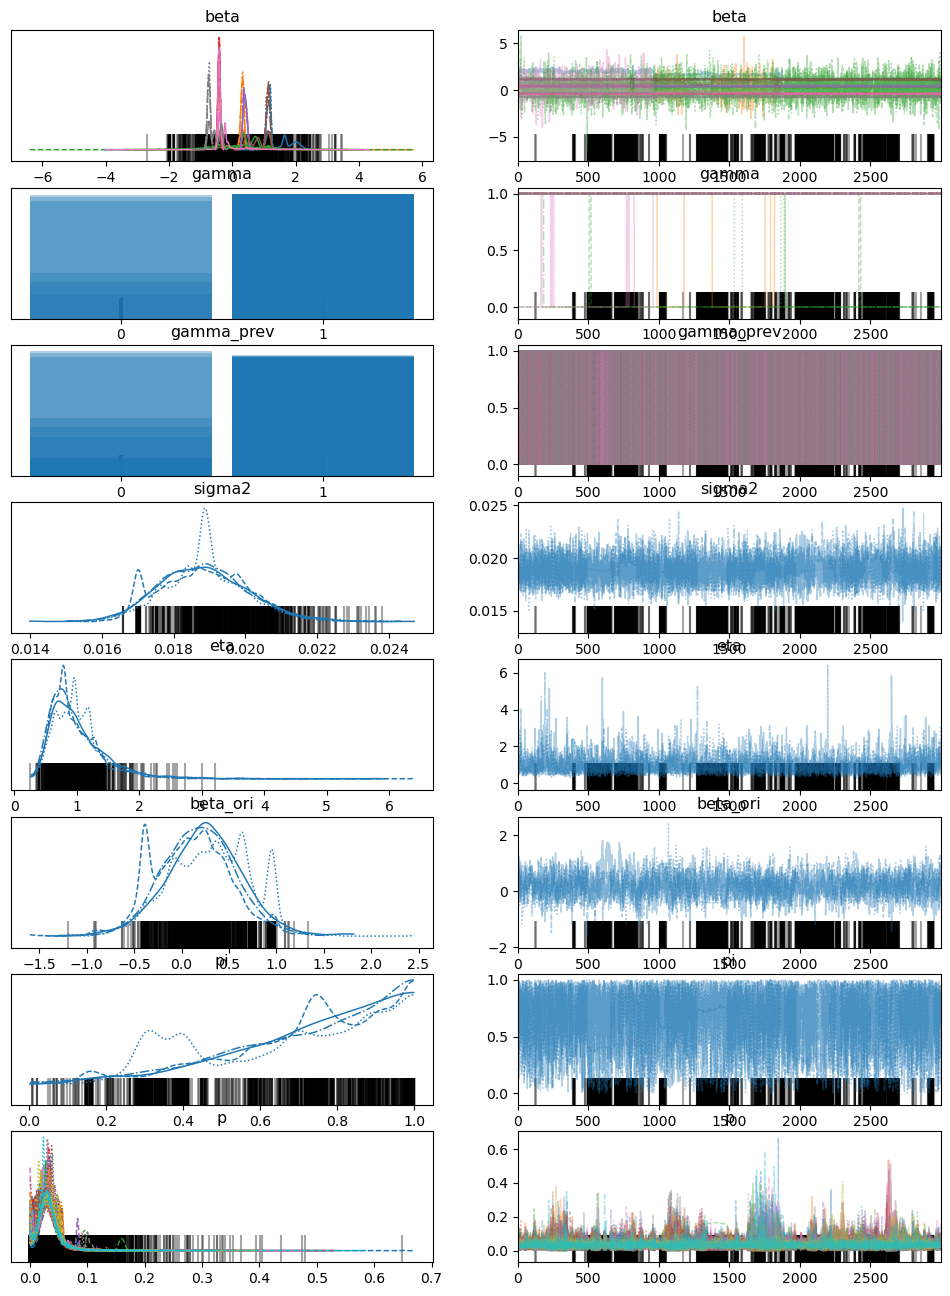

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]        1.253  0.270   0.997    1.986      0.117    0.088      10.0   
beta[1]        0.249  0.311  -0.428    0.419      0.088    0.064      18.0   
beta[2]        0.236  0.920  -1.606    1.977      0.058    0.041     222.0   
beta[3]       -0.418  0.034  -0.480   -0.354      0.001    0.001     590.0   
beta[4]        0.403  0.062   0.292    0.515      0.003    0.002     400.0   
beta[5]        1.051  0.201   0.484    1.238      0.088    0.066      10.0   
beta[6]       -0.330  0.384  -0.565    0.048      0.101    0.073      16.0   
beta[7]       -0.693  0.124  -0.829   -0.344      0.053    0.040      10.0   
gamma[0]       1.000  0.000   1.000    1.000      0.000    0.000   12000.0   
gamma[1]       0.950  0.217   1.000    1.000      0.042    0.030      27.0   
gamma[2]       0.182  0.386   0.000    1.000      0.163    0.122       6.0   
gamma[3]       1.000  0.000   1.000    1.000      0.000    0.000

In [593]:

# Step 1: Generate simulated data
np.random.seed(42)
N = 3000  # Number of samples
D = 8  # Number of predictors


# Step 2: Define the PyMC model
with pm.Model() as model:
    # Priors
    # Beta for regression coefficients, grouped into classes
    alpha = pm.HalfNormal("alpha", sigma=8.0)  # Dirichlet prior concentration parameter
    #alpha=1
    p = pm.Dirichlet("p", a=pm.math.ones(30) * alpha, shape=30)  # Class probabilities
 #10 0 1 2 3 4 
    S = pm.Categorical("S", p=p, shape=D)# bp=nel shape  1 1 1  # Class assignment for predictors (0-9)
    #[1 3 5 7 9]
    eta = pm.InverseGamma("eta", alpha=4, beta=4)  # Variance for beta_m
    mu_0=pm.Normal("beta_ori",mu=0,sigma=1)
    beta_m = pm.Normal("beta_m", mu=mu_0, sigma=pm.math.sqrt(eta), shape=30)  # Regression coefficients for each class
    
    # Ensure S only indexes valid categories of beta_m
    beta = pm.Deterministic("beta", beta_m[S])  # Map beta based on S
    
    # Sparsity indicator gamma
    pi = pm.Beta("pi", alpha=1, beta=1)  # Probability of gamma=1
    gamma_prev = pm.Bernoulli("gamma_prev", p=0.5, shape=D)  # 初始值
    rho = 0.8  # 控制gamma的平稳性（越接近1越稳定）
    gamma = pm.Bernoulli("gamma", p=rho * gamma_prev + (1 - rho) * pi, shape=D)

    #gamma = pm.Bernoulli("gamma", p=pi, shape=D)

    # Noise variance (sigma^2)
    sigma2 = pm.InverseGamma("sigma2", alpha=4, beta=4)  # Prior for noise variance

    # Observed data likelihood
    mu = pm.math.dot(X_with_intercept, beta * gamma)  # Predicted mean
    y_obs = pm.Normal("y_obs", mu=mu, sigma=pm.math.sqrt(sigma2), observed=y)

    # Inference
    
    trace = pm.sample(N, tune=500, chains=4,step=pm.NUTS(target_accept=0.95), return_inferencedata=True)


# Step 3: Analyze and visualize the results
az.plot_trace(trace, var_names=["beta", "gamma", "gamma_prev","sigma2", "eta", "beta_ori","pi", "p"])
plt.show()
summary=az.summary(trace, var_names=["beta", "gamma","gamma_prev", "sigma2", "eta","beta_ori", "pi", "p"])
print(summary)

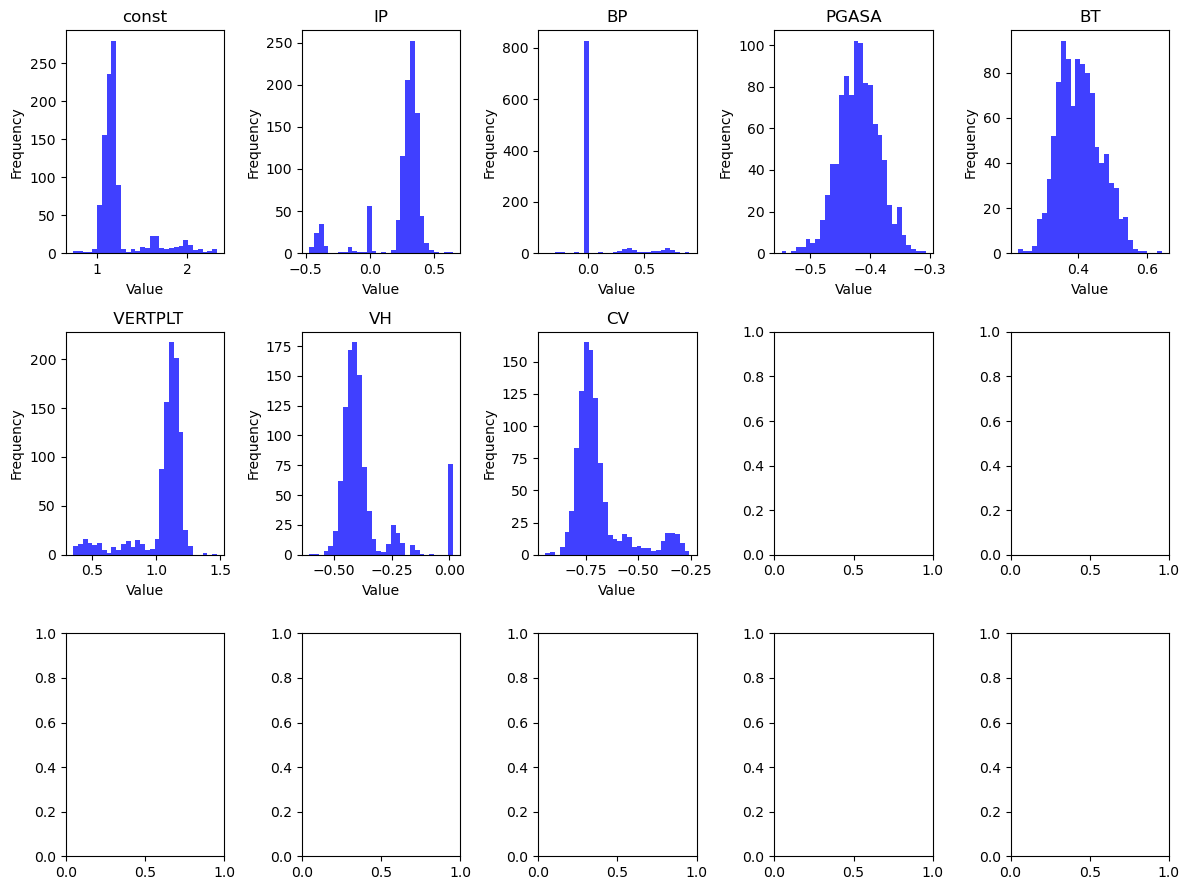

[1.    0.945 0.18  1.    1.    1.    0.927 1.   ]
[ 1.24790389  0.23894073  0.07903241 -0.41930468  0.40511577  1.05167474
 -0.3679194  -0.69151819]
[11.414 14.917 16.382 14.019 17.625 13.168 13.694 14.477]
1000 samples' R² values=: 0.9909


In [594]:
# 从后验中随机抽取 10 个样本
num_samples = 1000
posterior_indices = np.random.choice(
    trace.posterior["beta"].stack(samples=["chain", "draw"]).shape[1], 
    size=num_samples, 
    replace=False
)

# 定义新数据
 # 新数据 (10 个样本)

# 存储预测结果
beta_new_look = []
predictions = []
S_new = []
gamma_new=[]
for idx in posterior_indices:
    beta_sample = trace.posterior["beta"].stack(samples=["chain", "draw"]).values[:, idx]
    gamma_sample = trace.posterior["gamma"].stack(samples=["chain", "draw"]).values[:, idx]
    S_sample = trace.posterior["S"].stack(samples=["chain", "draw"]).values[:, idx]
    sigma_sample = np.sqrt(trace.posterior["sigma2"].stack(samples=["chain", "draw"]).values[idx])
    #gamma_binary = (gamma_post_mean > 0.5).astype(int)
    # 计算预测值
    mu_pred = X_with_intercept @ (beta_sample * gamma_sample)  # 预测均值
    y_pred = np.random.normal(mu_pred, sigma_sample, size=X_with_intercept.shape[0])  # 从预测分布采样
    S_new.append(gamma_sample*beta_sample)
    beta_new_look.append(S_sample)
    gamma_new.append(gamma_sample)
    predictions.append(y_pred)
S_new1 = np.array(S_new)
gamma_new = np.array(gamma_new)
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(12, 9))
axes = axes.flatten()

for i in range(8):
    ax = axes[i]
    # 只考虑 gamma 为 1 的情况
    #filtered_beta = S_new1[:, i][gamma_new[:, i] == 1]
    filtered_beta = S_new1[:, i]
    ax.hist(filtered_beta, bins=30, alpha=0.75, color='blue')
    ax.set_title(f'{X_with_intercept.columns[i]}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distribution.png', format='png', dpi=300, transparent=True)
plt.show()
S_mean_new = np.array(S_new).mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)
print(gamma_mean)

predictions = np.array(predictions).T  
pred_mean = predictions.mean(axis=1) 
print(S_mean_new)
print(beta_new_look_new)
SS_res = np.sum((pred_mean - y) ** 2)
SS_tot = np.sum((y - np.mean(y)) ** 2)
R_squared = 1 - (SS_res / SS_tot)
print(f"1000 samples' R² values=: {R_squared:.4f}")

In [596]:

trace.to_netcdf("refer_final_nemin_trace.nc")

# 查看并保存summary
summary_df = az.summary(trace, var_names=["beta", "gamma","gamma_prev", "sigma2", "beta_ori","eta", "pi", "p"])
print(summary_df)
summary_df.to_csv("refer_final_nemin_trace.csv")

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]        1.253  0.270   0.997    1.986      0.117    0.088      10.0   
beta[1]        0.249  0.311  -0.428    0.419      0.088    0.064      18.0   
beta[2]        0.236  0.920  -1.606    1.977      0.058    0.041     222.0   
beta[3]       -0.418  0.034  -0.480   -0.354      0.001    0.001     590.0   
beta[4]        0.403  0.062   0.292    0.515      0.003    0.002     400.0   
beta[5]        1.051  0.201   0.484    1.238      0.088    0.066      10.0   
beta[6]       -0.330  0.384  -0.565    0.048      0.101    0.073      16.0   
beta[7]       -0.693  0.124  -0.829   -0.344      0.053    0.040      10.0   
gamma[0]       1.000  0.000   1.000    1.000      0.000    0.000   12000.0   
gamma[1]       0.950  0.217   1.000    1.000      0.042    0.030      27.0   
gamma[2]       0.182  0.386   0.000    1.000      0.163    0.122       6.0   
gamma[3]       1.000  0.000   1.000    1.000      0.000    0.000

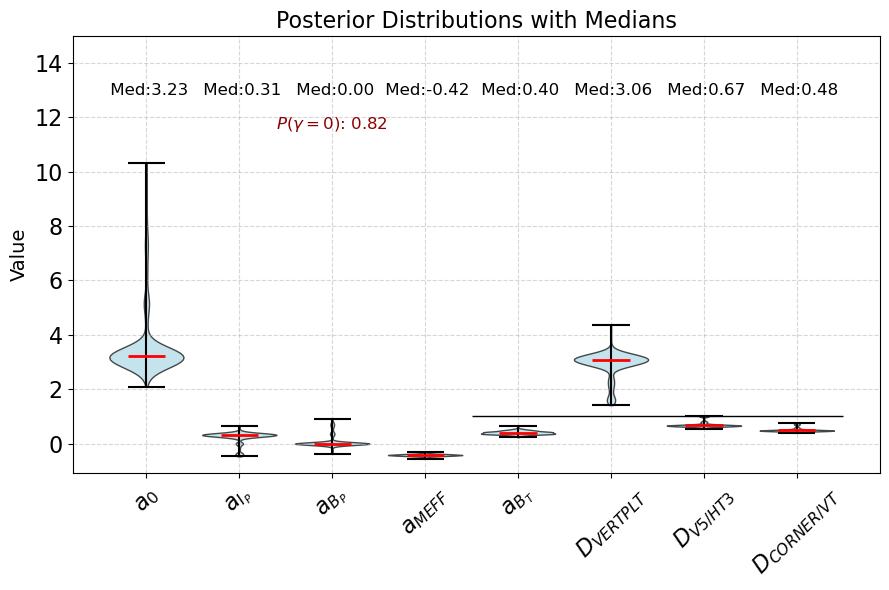


Gamma means: [1.    0.945 0.18  1.    1.    1.    0.927 1.   ]
S means: [ 1.24790389  0.23894073  0.07903241 -0.41930468  0.40511577  1.05167474
 -0.3679194  -0.69151819]
Beta new look means: [11.414 14.917 16.382 14.019 17.625 13.168 13.694 14.477]

Predictions shape: (486,)
1000 samples' RMSE: 0.0483


In [603]:
import numpy as np
import matplotlib.pyplot as plt

# 修改后的变量名称列表 - 将"D for XXX"改为"$D_{XXX}$"格式
titles = ["$a_0$", "$a_{I_P}$", "$a_{B_P}$","$a_{MEFF}$", "$a_{B_T}$", 
          "$D_{VERTPLT}$", "$D_{V5/HT3}$", "$D_{CORNER/VT}$"]

S_new1 = np.array(S_new)  # 转换为 NumPy 数组
gamma_new = np.array(gamma_new)  # 确保 gamma_new 是 NumPy 数组
D = 8  # 现在有6个变量

# 计算每个变量 gamma 为 0 的概率
gamma_prob_0 = np.mean(gamma_new < 0.5, axis=0)  # 概率 = (gamma < 0.5) 的均值

# 准备数据
data = []
for i in range(D):
    if i == 0 or i in [5, 6,7]:  # 需要exp变换的变量
        filtered_beta = np.exp(S_new1[:, i])
    else:
        filtered_beta = S_new1[:, i]
    data.append(filtered_beta)

# 创建图形
plt.figure(figsize=(9,6))  # 保持与原来相同的图形大小

# 创建小提琴图
violin_parts = plt.violinplot(data, 
                             showmeans=False, 
                             showmedians=True,
                             showextrema=True,
                             widths=0.8)

# 设置小提琴图的颜色和样式
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

# 设置统计线的样式
violin_parts['cmedians'].set_color('red')
violin_parts['cmedians'].set_linewidth(2)
violin_parts['cmaxes'].set_color('black')
violin_parts['cmins'].set_color('black')
violin_parts['cbars'].set_color('black')

# 设置x轴标签
xticks_pos = range(1, D+1)
plt.xticks(xticks_pos, titles, rotation=45, ha='center', fontsize=14)
# 从D_VERTPLT开始画水平实线
start_idx = 4  # D_VERTPLT是第5个变量（索引4）
x_start = start_idx + 1  # 小提琴图位置从1开始
ax = plt.gca()
ax.hlines(y=1.0, xmin=x_start-0.5, xmax=len(data)+0.5,
          colors='black', linestyles='-', linewidth=1)
# 在每个小提琴上方添加gamma=0的概率标注（仅当概率>0时显示）
for pos, i in zip(xticks_pos, range(D)):
    if gamma_prob_0[i] > 0.1:  # 只显示非零概率
        prob_text = f"$P(γ=0)$: {gamma_prob_0[i]:.2f}"
        plt.text(pos, plt.ylim()[1]*1.05, prob_text, 
                 ha='center', va='bottom', fontsize=12, color='darkred')
# 在每个小提琴上方添加中位数标注（Med: xxx）
y_max=np.max(S_new1)
# 计算中位数
medians = [np.median(d) for d in data]

# 获取当前 ylim，用于设定统一的高度
ylim = plt.ylim()
y_top = ylim[1]

# 仅显示后面五个变量的中位数（索引1到5，对应位置2到6）
for pos, median in zip(xticks_pos[0:], medians[0:]):
    plt.text(pos, y_top * 1.17, f" Med:{median:.2f}", 
             ha='center', va='bottom', fontsize=12, color='black')

# 调整 ylim 为显示足够空间
plt.ylim(ylim[0], y_top * 1.20)
# 添加网格和标签
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylabel('Value', fontsize=14)
plt.title('Posterior Distributions with Medians', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=16)

# 调整y轴范围，为标注留出空间
ylim = plt.ylim()
plt.ylim(ylim[0], ylim[1]*1.15)  # 增加15%的上部空间

# 调整布局
plt.tight_layout()
plt.savefig('refer_violin_plot_nemin.png', format='png', dpi=300, transparent=True)
plt.show()

# 其余统计计算保持不变
S_mean_new = S_new1.mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)  
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)

print("\nGamma means:", gamma_mean)
print("S means:", S_mean_new)
print("Beta new look means:", beta_new_look_new)

pred_mean = predictions.mean(axis=1)
print("\nPredictions shape:", pred_mean.shape)
rmse = np.sqrt(mean_squared_error(y, pred_mean))
print(f"1000 samples' RMSE: {rmse:.4f}")